# EDA по данным LMS Цифриум

Цель этого ноутбука — подготовить понятный и воспроизводимый аналитический слой для дальнейшего выбора целевого признака и обучения модели.

В этом ноутбуке мы **не пытаемся сразу построить финальный датасет любой ценой**. Вместо этого двигаемся поэтапно:

1. загружаем и выравниваем таблицы;
2. проверяем качество данных и ищем очевидные проблемы;
3. проводим черновую предобработку по каждой таблице отдельно;
4. строим только самые безопасные агрегаты и merge;
5. подготавливаем основу для проверки гипотез о более сложных связях между таблицами.

Базовая логика анализа:
- сначала техническая чистота данных;
- затем проверка корректности ключей и связей;
- только после этого — нетривиальные merge и построение сложных признаков.

In [57]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import gc

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path("C:\\Repos\\Xakaton\\data\\raw")

pd.set_option('display.max_rows', None)      # все строки
pd.set_option('display.max_columns', None)   # все столбцы
pd.set_option('display.width', None)         # не разрывать строки по ширине консоли
pd.set_option('display.max_colwidth', None)  # не обрезать текст внутри ячеек
pd.set_option('display.expand_frame_repr', False) # не переносить широкие таблицы на новые строки

## Этап 1. Загрузка данных и первичная подготовка

На этом этапе мы выполняем только базовые технические действия:

- читаем исходные таблицы;
- приводим даты к корректному типу;
- фиксируем размеры таблиц;
- проверяем, что данные доступны и читаются без потерь.

Важно: на этом этапе мы **ещё не делаем выводов о том, как именно таблицы нужно объединять**.  
Пока задача — аккуратно загрузить данные и подготовить их к первичному аудиту.

In [58]:
# award_badges даже не читаем - она не содержит никакой полезной инфы (кроме того, что награда №1 - для олимпиадников)

FILES = {
    "users_courses": "users_courses.csv",
    "user_answers": "user_answers.csv",
    "user_activity_histories": "user_activity_histories.csv",
    "user_trainings": "user_trainings.csv",
    "wk_users_courses_actions": "wk_users_courses_actions.csv",
    "lessons": "lessons.csv",
    "user_lessons": "user_lessons.csv",
    "wk_media_view_sessions": "wk_media_view_sessions.csv",
    "user_access_histories": "user_access_histories.csv",
    "user_award_badges": "user_award_badges.csv",
    "users": "users.csv"
}

DATE_COLS = {
    "users_courses": ["access_finished_at", "wk_officially_started_at", "wk_course_completed_at", "created_at", "updated_at"],
    "user_answers": ["submitted_at"],
    "user_activity_histories": ["created_at"],
    "user_trainings": ["started_at", "finished_at", "mark_saved_at"],
    "wk_users_courses_actions": ["created_at", "updated_at"],
    "wk_media_view_sessions": ["started_at"],
    "user_access_histories": ["access_started_at", "access_expired_at"],
    "user_award_badges": ["created_at"],
    "users": ["created_at", "grade_changed_at", "updated_at", "d_updated_at", "remember_created_at", "current_sign_in_at", "last_sign_in_at"],
    "lessons": ["wk_attendance_tracking_disabled_at"]
}

### Загрузка таблиц и приведение дат к корректному типу

Ниже определяются:
- список используемых файлов;
- словарь с колонками дат;
- функция загрузки всех таблиц в единый словарь `dfs`.

Такой формат удобен для дальнейшей работы, потому что позволяет:
- единообразно обращаться к таблицам;
- централизованно управлять схемой загрузки;
- быстро получать сводку по данным.

In [59]:
def load_all_tables(data_dir: Path, files: dict, date_cols: dict):
    dfs = {}
    overview = []
    for name, filename in files.items():
        path = data_dir / filename
        if not path.exists():
            print(f'!!! Не найден файл: {path}')
            continue
        parse_dates = date_cols.get(name, [])
        df = pd.read_csv(path, index_col=0, parse_dates=parse_dates, low_memory=False)
        dfs[name] = df
        overview.append({
            'table': name,
            'rows': len(df),
            'cols': df.shape[1],
            'memory_mb': round(df.memory_usage(deep=True).sum() / (1024**2), 2),
            'parsed_dates': len(parse_dates)
        })
    overview_df = pd.DataFrame(overview).sort_values('rows', ascending=False).reset_index(drop=True)
    return dfs, overview_df

dfs, tables_overview = load_all_tables(DATA_DIR, FILES, DATE_COLS)
tables_overview

,table,rows,cols,memory_mb,parsed_dates
0,user_answers,15176182,13,6610.98,1
1,wk_users_courses_actions,12909207,7,3203.60,2
2,user_lessons,3070664,11,844.95,0
3,user_activity_histories,3031137,3,433.17,1
4,wk_media_view_sessions,852358,6,182.51,1
5,user_access_histories,667124,4,87.80,2
6,user_trainings,427628,12,141.96,3
7,users_courses,290835,12,103.34,5
8,user_award_badges,252843,3,21.22,1
9,users,95395,21,70.32,7


### Проверка полных дубликатов

Перед любой предметной обработкой важно понять, есть ли в таблицах полные повторяющиеся строки.

На этом этапе мы:
- не удаляем дубликаты автоматически;
- сначала оцениваем их объём;
- затем интерпретируем их с учётом типа таблицы.

Это особенно важно для event-log и history-таблиц: там повторяющиеся строки не всегда означают ошибку выгрузки, а могут быть следствием особенностей логирования.

In [60]:
def summarize_duplicates(dfs: dict) -> pd.DataFrame:
    rows = []
    for name, df in dfs.items():
        dup_count = df.duplicated().sum()
        rows.append({
            'table': name,
            'rows': len(df),
            'duplicates': dup_count,
            'duplicates_%': round((dup_count / len(df)) * 100, 2) if len(df) else 0.0
        })
    summary = pd.DataFrame(rows).sort_values('duplicates_%', ascending=False)
    return summary

duplicate_report = summarize_duplicates(dfs)
duplicate_report

,table,rows,duplicates,duplicates_%
5,lessons,3369,1813,53.81
8,user_access_histories,667124,355372,53.27
4,wk_users_courses_actions,12909207,5490050,42.53
1,user_answers,15176182,4951291,32.63
7,wk_media_view_sessions,852358,22183,2.60
2,user_activity_histories,3031137,33312,1.10
0,users_courses,290835,0,0.00
6,user_lessons,3070664,0,0.00
3,user_trainings,427628,0,0.00
9,user_award_badges,252843,0,0.00


## Этап 2. Черновая предобработка таблиц

Ниже выполняется **черновая, безопасная предобработка**.

Под безопасной предобработкой здесь понимаются такие операции, которые:
- не требуют сильных предположений о связях между таблицами;
- не меняют зерно данных;
- не создают риск ошибочного merge;
- улучшают читаемость и пригодность таблиц к дальнейшему анализу.

На этом этапе мы в основном:
- приводим id к числовому виду;
- нормализуем булевые признаки;
- извлекаем простые признаки из сырых полей;
- удаляем только явно технические или бесполезные столбцы.

### Приведение идентификаторов к корректным типам

Для дальнейшего анализа важно, чтобы ключевые идентификаторы имели согласованные типы.

На этом этапе мы:
- приводим id-поля к числовому типу;
- устраняем проблемы, возникающие после чтения CSV;
- подготавливаем ключевые таблицы к последующим агрегатам и merge.

Это технический, но критически важный шаг: даже корректные связи между таблицами невозможно проверить, если ключи хранятся в несогласованных типах.

In [61]:
# Карта колонок для конвертации в целочисленный тип
INT_COLS_MAP = {
    'users_courses': ['user_id', 'course_id'],
    'user_answers': ['user_id', 'task_id'],
    'user_activity_histories': ['user_lesson_id'],
    'user_trainings': ['user_id', 'training_id'],
    'wk_users_courses_actions': ['user_id', 'users_course_id', 'lesson_id'],
    'lessons': ['course_id'],
    'user_lessons': ['user_id', 'lesson_id', 'group_id', 'users_course_id'],
    'user_award_badges': ['user_id'],
    'wk_media_view_sessions' : ['count', 'viewer_id'],
    'users': ['d_wk_school_id', 'sign_in_count', 'grade_id', 'd_wk_municipal_id', 'd_wk_region_id']
}

# конвертация
for tbl, cols in INT_COLS_MAP.items():
    for col in cols:
        if col not in dfs[tbl].columns:
            continue
        if pd.api.types.is_numeric_dtype(dfs[tbl][col]):
            continue 
        dfs[tbl][col] = pd.to_numeric(
            dfs[tbl][col].astype(str).str.replace(',', '', regex=False),
            errors='coerce'
        ).astype('Int64') 

### users — очистка пользовательского слоя и исключение учителей

Перед дальнейшими merge и проверками гипотез приводим таблицу `users` к базовому рабочему виду и исключаем из анализа учителей.

Это важно, потому что:
- целевой объект анализа — ученики;
- учителя и служебные аккаунты могут вносить шум в пользовательские таблицы;
- наличие teacher-аккаунтов может искажать агрегаты, распределения и результаты merge.

После очистки `users` удаляем соответствующие записи из остальных таблиц, где присутствуют пользовательские идентификаторы.

In [62]:
# ============================================================
# users: базовая очистка + исключение учителей
# ============================================================

# 1. Приводим ключ к единому имени
dfs["users"]["user_id"] = dfs["users"]["id"].copy()

# 2. Выделяем учителей
# True для teacher / agent аккаунтов
dfs["users"]["is_teacher"] = dfs["users"]["type"].astype("string").str.contains("Agent", na=False)

# 3. Сохраняем множества id до фильтрации
teacher_ids = set(dfs["users"].loc[dfs["users"]["is_teacher"], "user_id"])
pupil_ids = set(dfs["users"].loc[~dfs["users"]["is_teacher"], "user_id"])

print(f"Всего users: {len(dfs['users'])}")
print(f"Учителей: {len(teacher_ids)}")
print(f"Учеников: {len(pupil_ids)}")

# 4. Оставляем только учеников
dfs["users"] = (
    dfs["users"]
    .loc[~dfs["users"]["is_teacher"]]
    .drop(columns=["type", "is_teacher"], errors="ignore")
    .reset_index(drop=True)
)

dfs['users'] = dfs['users'].drop(columns=['current_sign_in_at', 'last_sign_in_at', 'grade_checked', 'xp', 'd_updated_at', 'id'])

display(dfs["users"].head())

Всего users: 95395
Учителей: 4748
Учеников: 90647


,last_explainer_seen_→_course,created_at,updated_at,remember_created_at,sign_in_count,grade_id,subscribed,timezone,grade_changed_at,d_wk_school_id,d_wk_municipal_id,d_wk_region_id,wk_gender,user_id
0,5.0,2025-04-25 12:57:00,"14 May, 2025, 19:43",2025-04-25 12:57:00,3,3003,True,Europe/Moscow,NaT,116371,96112,93938,2.0,675765
1,7.0,2025-05-22 19:01:00,"12 Jun, 2025, 12:47",2025-05-22 19:01:00,5,3007,True,Europe/Moscow,NaT,111130,95522,93512,2.0,679040
2,NaN,2025-05-23 09:47:00,"26 May, 2025, 06:54",2025-05-23 09:47:00,3,3006,True,Europe/Moscow,NaT,109819,94362,93594,1.0,679200
3,NaN,2025-05-16 08:38:00,"19 May, 2025, 07:12",2025-05-16 08:38:00,2,3009,True,Europe/Moscow,NaT,141024,93461,93460,2.0,678069
4,NaN,2025-06-19 06:47:00,"1 Nov, 2025, 09:18",2025-06-19 06:47:00,6,3010,True,Asia/Yekaterinburg,NaT,144581,144580,144579,NaN,693126


In [63]:
# ============================================================
# Удаляем teacher-аккаунты из всех таблиц
# ============================================================

def filter_out_teachers_from_all_tables(
    dfs: dict[str, pd.DataFrame],
    teacher_ids: set,
) -> pd.DataFrame:
    """
    Удаляет строки, связанные с teacher-аккаунтами, из всех таблиц,
    где встречаются user-like идентификаторы.
    """

    # user-like ключи, которые стоит проверить во всех таблицах
    candidate_user_cols = [
        "user_id",
    ]

    stats = []

    for table_name, df in dfs.items():
        before = len(df)
        filtered_df = df

        applied_cols = []

        for col in candidate_user_cols:
            if col in filtered_df.columns:
                filtered_df = filtered_df.loc[~filtered_df[col].isin(teacher_ids)].copy()
                applied_cols.append(col)

        after = len(filtered_df)
        removed = before - after

        dfs[table_name] = filtered_df

        stats.append({
            "table": table_name,
            "checked_columns": ", ".join(applied_cols) if applied_cols else "",
            "rows_before": before,
            "rows_after": after,
            "rows_removed": removed,
            "share_removed": removed / before if before > 0 else 0.0,
        })

    return pd.DataFrame(stats).sort_values("rows_removed", ascending=False).reset_index(drop=True)


teacher_filter_stats = filter_out_teachers_from_all_tables(dfs, teacher_ids)
display(teacher_filter_stats)

,table,checked_columns,rows_before,rows_after,rows_removed,share_removed
0,wk_users_courses_actions,user_id,12909207,12633684,275523,0.021343
1,user_answers,user_id,15176182,14955799,220383,0.014522
2,user_lessons,user_id,3070664,3008595,62069,0.020214
3,users_courses,user_id,290835,267206,23629,0.081245
4,user_trainings,user_id,427628,421814,5814,0.013596
5,user_award_badges,user_id,252843,252831,12,0.000047
6,user_activity_histories,,3031137,3031137,0,0.000000
7,lessons,,3369,3369,0,0.000000
8,wk_media_view_sessions,,852358,852358,0,0.000000
9,user_access_histories,,667124,667124,0,0.000000


### users_courses — черновая предобработка

`users_courses` — одна из центральных таблиц анализа, потому что именно она задаёт уровень наблюдения  
**пользователь × курс**.

На этом этапе мы извлекаем из неё только простые и надёжные признаки:
- признаки активности;
- базовые производные флаги;
- технически полезные преобразования без сложных предположений о поведении пользователя.

Важно: пока мы рассматриваем `users_courses` как базовую таблицу для дальнейшего объединения признаков, но не пытаемся через неё сразу восстановить все связи с журналами действий.

In [64]:
# 1. state → is_active (булев флаг)
dfs['users_courses']['is_active'] = dfs['users_courses']['state'].str.lower().eq('active')

# 2. Конвертация "числовых строк" в numeric
for col in ['wk_max_points', 'wk_max_task_count']:
    dfs['users_courses'][col] = pd.to_numeric(dfs['users_courses'][col], errors='coerce')

# 3. Нормализация прогресса: wk_points / wk_max_points → progress_pct
dfs['users_courses']['progress_pct'] = np.where(
    (dfs['users_courses']['wk_max_points'] > 0) & (dfs['users_courses']['wk_max_points'].notna()),
    (dfs['users_courses']['wk_points'] / dfs['users_courses']['wk_max_points'] * 100).round(2),
    np.nan 
)

dfs['users_courses'] = dfs['users_courses'].drop(columns=['state', 'wk_points']) 

### user_answers — черновая предобработка

Таблица `user_answers` содержит ответы пользователя и потенциально богата поведенческой информацией,  
но в сыром виде она неудобна для анализа.

На этом этапе мы:
- нормализуем булевые признаки;
- разбираем вложенные JSON-поля;
- извлекаем простые атомарные признаки из структуры ответа.

Пока это именно черновая подготовка таблицы.  
Вопрос о том, как корректно агрегировать `user_answers` и можно ли считать её признаки course-level, будет решаться отдельно на этапе гипотез.

In [65]:
# 1. Конвертация в bool (учитывает регистр, пробелы и безопасно обрабатывает NaN)
for col in ['solved', 'skipped', 'wk_partial_answer']:
    dfs['user_answers'][col] = dfs['user_answers'][col].astype(str).str.strip().str.lower().eq('true')

# 2. Нормализация попыток: attempts / max_attempts → attempts_pct
dfs['user_answers']['attempts_pct'] = np.where(
    (dfs['user_answers']['max_attempts'] > 0) & (dfs['user_answers']['max_attempts'].notna()),
    (dfs['user_answers']['attempts'] / dfs['user_answers']['max_attempts'] * 100).round(2),
    np.nan
)

# 3. Создание бинарных флагов по типу ресурса
dfs['user_answers']['is_lesson'] = dfs['user_answers']['resource_type'].eq('Lesson')
dfs['user_answers']['is_training'] = dfs['user_answers']['resource_type'].eq('Training')
dfs['user_answers']['is_hw'] = dfs['user_answers']['resource_type'].eq('Homework')

# 4. Удаляем лишние столбцы
dfs['user_answers'] = dfs['user_answers'].drop(columns=['performance', 'attempts', 'resource_type'])

In [66]:
# 1. Парсим JSON-строки в списки
dfs['user_answers']['parsed_results'] = dfs['user_answers']['results'].apply(
    lambda x: json.loads(x) if isinstance(x, str) else []
)

# 2. Раскрываем списки: каждый элемент списка → отдельная строка
dfs['user_answers'] = dfs['user_answers'].explode('parsed_results').reset_index(drop=True)

# 3. Извлекаем поля из словарей
dicts = dfs['user_answers']['parsed_results']

In [67]:
dfs['user_answers']['result_subtask_id'] = [next(iter(d.keys()), None) if isinstance(d, dict) else None for d in dicts]
dfs['user_answers']['result_points'] = [next(iter(d.values()), {}).get('points', None) if isinstance(d, dict) else None for d in dicts]
dfs['user_answers']['result_coefficient'] = [next(iter(d.values()), {}).get('coefficient', None) if isinstance(d, dict) else None for d in dicts]

dfs['user_answers']['result_subtask_id'] = dfs['user_answers']['result_subtask_id'].astype('Int64')
dfs['user_answers']['result_points'] = dfs['user_answers']['result_points'].astype('float32')
dfs['user_answers']['result_coefficient'] = dfs['user_answers']['result_coefficient'].astype('float32')

dfs['user_answers'] = dfs['user_answers'].drop(columns=['parsed_results', 'results'])

### user_activity_histories — черновая предобработка

Таблица `user_activity_histories` описывает отдельные действия пользователя внутри учебного процесса.

На текущем этапе мы:
- выделяем простые бинарные флаги по типам действий;
- не агрегируем таблицу слишком рано;
- не делаем выводов о способе её финального merge.

Это подготовительный шаг перед последующей проверкой того, как именно события из этой таблицы связаны с уроками, курсами и пользовательским прогрессом.

In [68]:
# 1. Создание бинарных флагов по типу действия
dfs['user_activity_histories']['is_visit_video'] = dfs['user_activity_histories']['action'].eq('visit_video')
dfs['user_activity_histories']['is_visit_translation'] = dfs['user_activity_histories']['action'].eq('visit_translation')
dfs['user_activity_histories']['is_show_conspect'] = dfs['user_activity_histories']['action'].eq('show_conspect')

dfs['user_activity_histories'] = dfs['user_activity_histories'].drop(columns=['action'])

### user_trainings — черновая предобработка

`user_trainings` содержит информацию о тренировках пользователя и их типах.

На этапе черновой обработки мы:
- выделяем бинарные признаки по типу тренировки;
- сохраняем таблицу в максимально информативном виде;
- не агрегируем её преждевременно.

Это важно, потому что сама по себе таблица информативна, но способ её корректного использования в итоговом датасете требует отдельной гипотезы.

In [69]:
dfs['user_trainings']['is_lesson_training'] = dfs['user_trainings']['type'].eq('UserTrainings::LessonTraining')
dfs['user_trainings']['is_regular_training'] = dfs['user_trainings']['type'].eq('UserTrainings::RegularTraining')
dfs['user_trainings']['is_olympiad_training'] = dfs['user_trainings']['type'].eq('UserTrainings::OlympiadTraining')

dfs['user_trainings']['is_started'] = dfs['user_trainings']['state'].eq('started')

dfs['user_trainings'] = dfs['user_trainings'].drop(columns=['type', 'state'])

### wk_users_courses_actions — черновая предобработка

Эта таблица содержит журнал действий пользователя внутри курса и потенциально является одним из ключевых источников поведенческих признаков.

На текущем этапе мы:
- переводим типы действий в простые бинарные индикаторы;
- оставляем таблицу в event-level виде;
- не агрегируем её до тех пор, пока отдельно не определим корректное зерно будущего merge.

Именно такие таблицы особенно важно сначала подготовить технически, а уже потом использовать для построения признаков.

In [70]:
# 1. Создание бинарных флагов по типу действия в курсе
dfs['wk_users_courses_actions']['is_visit_video'] = dfs['wk_users_courses_actions']['action'].eq('visit_video')
dfs['wk_users_courses_actions']['is_show_conspect'] = dfs['wk_users_courses_actions']['action'].eq('visit_preparation_material')
dfs['wk_users_courses_actions']['is_start_training'] = dfs['wk_users_courses_actions']['action'].eq('start_training')
dfs['wk_users_courses_actions']['is_user_answer'] = dfs['wk_users_courses_actions']['action'].eq('user_answer')
dfs['wk_users_courses_actions']['is_visit_translation'] = dfs['wk_users_courses_actions']['action'].eq('visit_translation')
dfs['wk_users_courses_actions']['is_scratch_playground_visited'] = dfs['wk_users_courses_actions']['action'].eq('scratch_playground_visited')

dfs['wk_users_courses_actions'] = dfs['wk_users_courses_actions'].drop(columns=['action', 'sourceable_id', 'lesson_id'])

### user_award_badges — первичная агрегация

В отличие от событийных таблиц, `user_award_badges` естественно агрегируется до уровня пользователя.

Здесь мы строим простые user-level признаки:
- факт наличия определённых наград;
- дата первого получения награды;
- удобное wide-представление для последующего merge с таблицей пользователей.

Это один из первых примеров безопасной агрегации, потому что смысл таблицы изначально user-level.

In [71]:
# 1. Агрегируем даты первого получения наград по пользователям
dates_wide = dfs['user_award_badges'].pivot_table(
    index='user_id', columns='award_badge_id', values='created_at', aggfunc='min'
)
dates_wide.columns = [f'date_badge_{int(c)}' for c in dates_wide.columns]

# 2. Формируем булевы флаги достижения (True, если есть дата)
flags_wide = dates_wide.notna()
flags_wide.columns = [f'has_badge_{int(c[-1])}' for c in dates_wide.columns]

# 3. Объединяем флаги и даты в одну таблицу, возвращаем user_id в колонки
dfs['user_award_badges'] = pd.concat([flags_wide, dates_wide], axis=1).reset_index()

### Наблюдение по наградам

По данным видно, что пользователь не получает бейджи `1` и `6` одновременно:  
эти награды, вероятно, соответствуют взаимоисключающим статусам.

Такое наблюдение полезно, потому что:
- подтверждает внутреннюю согласованность таблицы наград;
- помогает аккуратнее интерпретировать признаки;
- подсказывает, какие признаки могут быть избыточными или взаимоисключающими.

### users + user_award_badges — безопасный user-level merge

На этом этапе объединяем профиль пользователя и агрегированные признаки по наградам.

Это безопасный merge, потому что:
- обе части имеют естественное user-level зерно;
- ключ объединения однозначен (`user_id`);
- такой merge не требует сложных предположений о курсах, уроках и событиях.

Итоговая таблица пользователей будет позже использоваться как user-level enrichment для основной таблицы анализа.

In [72]:
#dfs['users']['user_id'] = dfs['users']['id'].copy()

#dfs['users'] = dfs['users'].drop(columns=['is_teacher', 'current_sign_in_at', 'last_sign_in_at', 'grade_checked', 'xp', 'd_updated_at', 'id'])

In [73]:
# type → is_teacher (булев флаг: True для User::Agent)
#dfs['users']['is_teacher'] = dfs['users']['type'].str.contains('Agent', na=False)
#dfs['users'] = dfs['users'][dfs['users'].is_teacher == False].reset_index(drop=True)
#dfs['users'] = dfs['users'].drop(columns=['type', 'is_teacher'])

# 1. Соединение: добавляем данные о наградах к профилям пользователей 
dfs['users'] = dfs['users'].merge(dfs['user_award_badges'], on='user_id', how='left')

# 2. Заполняем пропуски в булевых флагах: нет записи = награда не получена (False)
for col in dfs['users'].columns:
    if col.startswith('has_badge_'):
        dfs['users'][col] = dfs['users'][col].fillna(False).astype(bool)

In [74]:
del dfs['user_award_badges']

### user_access_histories — черновая предобработка

Таблица `user_access_histories` описывает историю выдачи и отзыва доступа.

На этапе черновой обработки мы:
- выделяем типы активаторов доступа;
- подготавливаем таблицу к последующему анализу;
- пока не делаем окончательных выводов о том, как именно её агрегировать и присоединять.

Это важная таблица для будущих гипотез, потому что она может помочь объяснять доступность курса, изменение статуса пользователя и возможные причины оттока.

In [75]:
# 1. Создание бинарных флагов по типу активатора доступа
dfs['user_access_histories']['is_premium_access'] = dfs['user_access_histories']['activator_class'].eq('Courses::AccessActivators::PremiumAccessActivator')
dfs['user_access_histories']['is_revoke_access'] = dfs['user_access_histories']['activator_class'].eq('Courses::AccessActivators::RevokeAccessActivator')
dfs['user_access_histories']['is_standard_access'] = dfs['user_access_histories']['activator_class'].eq('Courses::AccessActivators::StandardAccessActivator')
dfs['user_access_histories']['is_change_duration_access'] = dfs['user_access_histories']['activator_class'].eq('Courses::AccessActivators::ChangeAccessDurationActivator')
dfs['user_access_histories']['is_month_premium_access'] = dfs['user_access_histories']['activator_class'].eq('Courses::AccessActivators::MonthPremiumAccessActivator')

dfs['user_access_histories'] = dfs['user_access_histories'].drop(columns=['activator_class'])

## Этап 3. Проверка гипотез и выполнение обоснованных merge

После черновой предобработки таблиц переходим к следующему этапу: проверяем, какие объединения таблиц действительно можно считать корректными.

На этом этапе мы не выполняем merge автоматически. Вместо этого для каждого нетривиального объединения используем одинаковую схему:

1. подготавливаем данные к проверке гипотезы;
2. проверяем гипотезу с помощью метрик и графиков;
3. выполняем merge только в том случае, если гипотеза подтверждается.

Такой подход позволяет сделать пайплайн более прозрачным и избежать неочевидных ошибок при объединении таблиц.

### Гипотеза 1. Course-level агрегация `lessons` согласуется с `users_courses`

#### 3.1.0. Подготовка `users_courses` к проверке гипотезы

Перед проверкой гипотезы не изменяем исходную таблицу `users_courses`, а строим временный срез данных только для валидации.

Из этого среза исключаем:
- строки с пропусками в ключевых course-level полях:
  - `wk_max_points`
  - `wk_max_task_count`
  - `wk_max_viewable_lessons`
- курсы с слишком малым числом наблюдений, так как они создают шум и не позволяют надёжно судить о корректности сравнения с `lessons`.

После этого проверяем гипотезу только на достаточно полных и устойчивых представителях `users_courses`.

#### 3.1.1 Подготовка данных к проверке гипотезы

Убрем заведомо плохие строки

In [76]:
# ============================================================
# 3.1.1. Временный срез users_courses для проверки гипотезы
# Не меняем dfs["users_courses"]
# ============================================================

MIN_ROWS_PER_COURSE = 10

users_courses_hypothesis = dfs["users_courses"].copy()

# 1. Убираем строки с NaN в ключевых course-level полях
key_course_cols = [
    "wk_max_points",
    "wk_max_task_count",
    "wk_max_viewable_lessons",
]

users_courses_hypothesis = users_courses_hypothesis.dropna(subset=key_course_cols).copy()

# 2. Убираем шумные курсы с слишком малым числом строк
course_sizes_hypothesis = (
    users_courses_hypothesis
    .groupby("course_id", dropna=False)
    .size()
    .reset_index(name="rows_count")
)

valid_course_ids_by_size = set(
    course_sizes_hypothesis.loc[
        course_sizes_hypothesis["rows_count"] >= MIN_ROWS_PER_COURSE,
        "course_id"
    ]
)

small_courses = course_sizes_hypothesis.loc[
    course_sizes_hypothesis["rows_count"] < MIN_ROWS_PER_COURSE
].copy()

users_courses_hypothesis = users_courses_hypothesis[
    users_courses_hypothesis["course_id"].isin(valid_course_ids_by_size)
].copy()

print("Исходных строк users_courses:", len(dfs["users_courses"]))
print("После удаления NaN в ключевых course-level полях:", len(dfs["users_courses"].dropna(subset=key_course_cols)))
print("После удаления малых курсов:", len(users_courses_hypothesis))
print("Удалено малых course_id:", len(small_courses))

display(small_courses.sort_values("rows_count").head(20))

Исходных строк users_courses: 267206
После удаления NaN в ключевых course-level полях: 267080
После удаления малых курсов: 266993
Удалено малых course_id: 29


,course_id,rows_count
20,841,1
19,839,1
67,1044,1
49,958,1
42,947,1
37,941,1
36,940,1
35,938,1
66,1042,1
61,1034,2


#### 3.1.2 Агрегация Lessons

В датасете нет отдельной таблицы курсов, поэтому course-level представление курса мы строим из таблицы `lessons`.

Для проверки гипотезы:
- берём уже построенные агрегированные признаки из `lessons`;
- выделяем из `users_courses` course-level поля;
- приводим обе таблицы к одному уровню сравнения: одна строка на `course_id`.

После этого можно проверить, насколько агрегаты из `lessons` согласуются с характеристиками курса, уже присутствующими в `users_courses`.

In [77]:
def build_course_features_from_lessons(lessons: pd.DataFrame) -> pd.DataFrame:
    """
    @brief Строит агрегированные признаки по course_id на основе lessons.csv.

    Основной принцип:
    - берём только проверяемую информацию из самой таблицы lessons;
    - не считаем task_expected / conspect_expected абсолютной истиной,
      а используем их вместе с observed-признаками и mismatch-счётчиками.

    @param lessons Исходный DataFrame lessons.csv.
    @return pd.DataFrame Таблица признаков в разрезе course_id.
    """
    df = lessons.copy()

    # ------------------------------------------------------------
    # 1) Приведение типов
    # ------------------------------------------------------------
    numeric_cols = [
        "lesson_number",
        "wk_max_points",
        "wk_task_count",
        "wk_video_duration",
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    bool_cols = [
        "conspect_expected",
        "task_expected",
        "wk_survival_training_expected",
        "wk_scratch_playground_enabled",
        "wk_attendance_tracking_enabled",
    ]
    for col in bool_cols:
        df[col] = df[col].fillna(False).astype(bool)

    # ------------------------------------------------------------
    # 2) Устойчивые row-level признаки
    # ------------------------------------------------------------
    # Есть ли номер урока
    df["has_lesson_number"] = df["lesson_number"].notna()

    # Наблюдаемые задачи: считаем это более надёжным, чем один только task_expected
    df["has_tasks_observed"] = (
        df["wk_task_count"].fillna(0).gt(0)
        | df["wk_max_points"].fillna(0).gt(0)
    )

    # Есть ли видео
    df["has_video"] = df["wk_video_duration"].fillna(0).gt(0)

    # Было ли явно отключено отслеживание посещаемости
    df["attendance_disabled_marked"] = df["wk_attendance_tracking_disabled_at"].notna()

    # ------------------------------------------------------------
    # 3) Диагностические признаки качества данных
    # ------------------------------------------------------------
    # task_expected=False, но по факту задачи/баллы есть
    df["task_flag_mismatch"] = (~df["task_expected"]) & df["has_tasks_observed"]

    # Отношение "баллы на одну задачу" — полезный агрегат сложности/оценивания
    valid_task_rows = df["wk_task_count"].fillna(0).gt(0) & df["wk_max_points"].notna()
    df["points_per_task"] = np.where(
        valid_task_rows,
        df["wk_max_points"] / df["wk_task_count"],
        np.nan,
    )

    # Доля строк, где max_points ~= task_count
    df["points_equal_task"] = np.where(
        valid_task_rows,
        np.isclose(df["wk_max_points"], df["wk_task_count"], atol=1e-9),
        np.nan,
    )

    # ------------------------------------------------------------
    # 4) Агрегация по курсам
    # ------------------------------------------------------------
    course_features = (
        df.groupby("course_id", dropna=False)
        .agg(
            # Размер и структура набора уроков курса
            lessons_total_count=("course_id", "size"),
            lessons_with_number_count=("has_lesson_number", "sum"),

            # Флаги конфигурации
            lessons_with_conspect_count=("conspect_expected", "sum"),
            lessons_task_expected_rows=("task_expected", "sum"),
            lessons_attendance_enabled_rows=("wk_attendance_tracking_enabled", "sum"),
            lessons_attendance_disabled_marked_rows=("attendance_disabled_marked", "sum"),
            lessons_survival_rows=("wk_survival_training_expected", "sum"),
            lessons_scratch_rows=("wk_scratch_playground_enabled", "sum"),

            # Наблюдаемая задача / нагрузка
            lessons_rows_with_tasks_observed=("has_tasks_observed", "sum"),
            lessons_task_count_sum=("wk_task_count", "sum"),
            lessons_task_count_mean=("wk_task_count", "mean"),
            lessons_task_count_max=("wk_task_count", "max"),

            # Балльная система
            lessons_max_points_sum=("wk_max_points", "sum"),
            lessons_max_points_mean=("wk_max_points", "mean"),
            lessons_max_points_max=("wk_max_points", "max"),
            lessons_points_per_task_mean=("points_per_task", "mean"),
            lessons_points_equal_task_share=("points_equal_task", "mean"),

            # Видео
            lessons_rows_with_video=("has_video", "sum"),
            lessons_video_duration_sum=("wk_video_duration", "sum"),
            lessons_video_duration_mean=("wk_video_duration", "mean"),
            lessons_video_duration_max=("wk_video_duration", "max"),

            # Диагностика качества данных
            lessons_task_flag_mismatch_rows=("task_flag_mismatch", "sum"),
        )
        .reset_index()
    )

    # ------------------------------------------------------------
    # 5) Доли / coverage-признаки
    # ------------------------------------------------------------
    denom = course_features["lessons_total_count"].replace(0, np.nan)

    share_map = {
        "lessons_with_number_share": "lessons_with_number_count",
        "lessons_conspect_expected_share": "lessons_with_conspect_count",
        "lessons_task_expected_share": "lessons_task_expected_rows",
        "lessons_tasks_observed_share": "lessons_rows_with_tasks_observed",
        "lessons_video_share": "lessons_rows_with_video",
        "lessons_attendance_enabled_share": "lessons_attendance_enabled_rows",
        "lessons_survival_share": "lessons_survival_rows",
        "lessons_scratch_share": "lessons_scratch_rows",
        "lessons_task_flag_mismatch_share": "lessons_task_flag_mismatch_rows",
    }

    for new_col, base_col in share_map.items():
        course_features[new_col] = course_features[base_col] / denom

    return course_features.sort_values("course_id").reset_index(drop=True)

dfs["courses"] = build_course_features_from_lessons(dfs["lessons"])

In [78]:
cols = ['course_id', 'lessons_total_count', 
       
'lessons_task_count_sum', 
'lessons_task_count_mean',
'lessons_task_count_max', 
'lessons_max_points_sum',
'lessons_max_points_mean', 
'lessons_max_points_max',
'lessons_points_per_task_mean', 
'lessons_video_duration_sum',
'lessons_video_duration_mean', 
'lessons_video_duration_max',

'lessons_points_equal_task_share',
'lessons_with_number_share',
'lessons_conspect_expected_share',
'lessons_task_expected_share',
'lessons_tasks_observed_share',
'lessons_video_share',
'lessons_attendance_enabled_share', 
'lessons_survival_share',
'lessons_scratch_share', 
'lessons_task_flag_mismatch_share'
]

dfs["courses"] = dfs["courses"][cols].fillna(0)

#### 3.2.0 Проверка гипотезы

Проверяем, насколько агрегированные course-level признаки, построенные из `lessons`, согласуются с course-level полями в `users_courses`.

Сравниваем:
- `lessons_max_points_sum` и `wk_max_points`;
- `lessons_task_count_sum` и `wk_max_task_count`;
- `lessons_total_count` и `wk_max_viewable_lessons`.

Для этого:
- строим reference-таблицу по курсам из `users_courses`;
- считаем метрики согласованности;
- строим графики;
- отдельно смотрим курсы с наибольшими расхождениями.

Для начала проверим у всех ли курсов для всех юзеров одинаковые данные (в рамках одного и того же course_id)

In [79]:

# Берем только поля, нужные для проверки гипотезы
users_courses_ref_raw = dfs["users_courses"][
    ["course_id", "wk_max_points", "wk_max_task_count", "wk_max_viewable_lessons"]
].copy()

# Сначала проверяем, одинаковы ли course-level поля внутри одного course_id
users_courses_consistency = (
    users_courses_ref_raw
    .groupby("course_id", dropna=False)
    .agg(
        n_rows=("course_id", "size"),
        n_wk_max_points=("wk_max_points", "nunique"),
        n_wk_max_task_count=("wk_max_task_count", "nunique"),
        n_wk_max_viewable_lessons=("wk_max_viewable_lessons", "nunique"),
    )
    .reset_index()
)

inconsistent_courses = users_courses_consistency[
    (users_courses_consistency["n_wk_max_points"] > 1) |
    (users_courses_consistency["n_wk_max_task_count"] > 1) |
    (users_courses_consistency["n_wk_max_viewable_lessons"] > 1)
].copy()

print(f"Число course_id с непоследовательными course-level полями в users_courses: {len(inconsistent_courses)}")
display(inconsistent_courses.head(10))

Число course_id с непоследовательными course-level полями в users_courses: 14


,course_id,n_rows,n_wk_max_points,n_wk_max_task_count,n_wk_max_viewable_lessons
8,762,9,2,2,1
9,763,58078,2,2,1
15,770,58075,2,1,2
16,771,45061,4,3,1
17,772,41560,2,1,2
47,952,1062,3,3,3
50,955,729,4,4,4
53,990,5337,1,1,2
56,993,1113,1,1,2
57,1026,333,2,1,2


In [80]:
# course_id, у которых course-level поля внутри users_courses консистентны
valid_course_ids = users_courses_consistency[
    (users_courses_consistency["n_wk_max_points"] == 1) &
    (users_courses_consistency["n_wk_max_task_count"] == 1) &
    (users_courses_consistency["n_wk_max_viewable_lessons"] == 1)
]["course_id"]

users_courses_ref = (
    users_courses_ref_raw[
        users_courses_ref_raw["course_id"].isin(valid_course_ids)
    ]
    .groupby("course_id", dropna=False)
    .agg(
        wk_max_points=("wk_max_points", "first"),
        wk_max_task_count=("wk_max_task_count", "first"),
        wk_max_viewable_lessons=("wk_max_viewable_lessons", "first"),
    )
    .reset_index()
    .sort_values("course_id")
    .reset_index(drop=True)
)

print("Число консистентных course_id:", len(users_courses_ref))
display(users_courses_ref.head())

Число консистентных course_id: 64


,course_id,wk_max_points,wk_max_task_count,wk_max_viewable_lessons
0,754,71.0,71.0,20.0
1,755,5.0,1.0,0.0
2,756,0.0,0.0,2.0
3,757,0.0,0.0,24.0
4,758,0.0,0.0,6.0


In [81]:
problem_course_ids = set(inconsistent_courses["course_id"])

total_rows = len(dfs["users_courses"])
problem_rows = dfs["users_courses"]["course_id"].isin(problem_course_ids).sum()
problem_share = problem_rows / total_rows

print(f"Всего строк в users_courses: {total_rows}")
print(f"Строк с проблемными course_id: {problem_rows}")
print(f"Доля строк с проблемными course_id: {problem_share:.4%}")

Всего строк в users_courses: 267206
Строк с проблемными course_id: 221063
Доля строк с проблемными course_id: 82.7313%


In [82]:
total_courses = dfs["users_courses"]["course_id"].nunique(dropna=True)
problem_courses_cnt = len(problem_course_ids)
problem_courses_share = problem_courses_cnt / total_courses

print(f"Всего уникальных course_id: {total_courses}")
print(f"Проблемных course_id: {problem_courses_cnt}")
print(f"Доля проблемных course_id: {problem_courses_share:.4%}")

Всего уникальных course_id: 82
Проблемных course_id: 14
Доля проблемных course_id: 17.0732%


In [83]:
problem_course_distribution = (
    dfs["users_courses"]
    .loc[dfs["users_courses"]["course_id"].isin(problem_course_ids), "course_id"]
    .value_counts()
    .rename_axis("course_id")
    .reset_index(name="rows_count")
)

problem_course_distribution["rows_share_in_users_courses"] = (
    problem_course_distribution["rows_count"] / len(dfs["users_courses"])
)

display(problem_course_distribution.head(20))

,course_id,rows_count,rows_share_in_users_courses
0,763,58078,0.217353
1,770,58075,0.217342
2,771,45061,0.168638
3,772,41560,0.155535
4,170000688,5641,0.021111
5,990,5337,0.019973
6,1103,2368,0.008862
7,993,1113,0.004165
8,1033,1104,0.004132
9,952,1062,0.003974


Как видим >80% курсов имеют разную наполненность для разных курсов, определим аномальные строки

Для этого возьмем агрегацию по lessons в качестве референца, предположим что это эталонная разбивка баллов и найдем стрроки не совпадающие с эталоном

In [84]:
# reference course-level значения из lessons
course_reference = dfs["courses"][
    [
        "course_id",
        "lessons_max_points_sum",
        "lessons_task_count_sum",
        "lessons_total_count",
    ]
].copy()

course_reference = course_reference.rename(
    columns={
        "lessons_max_points_sum": "ref_max_points",
        "lessons_task_count_sum": "ref_task_count",
        "lessons_total_count": "ref_lessons_count",
    }
)

display(course_reference.head())

,course_id,ref_max_points,ref_task_count,ref_lessons_count
0,754,71.0,71.0,21
1,755,5.0,1.0,1
2,756,0.0,0.0,2
3,757,0.0,0.0,24
4,758,0.0,0.0,6


Сгруппируем курсы вделяя их сигнатуру для сравнения с lessons

In [85]:

# ============================================================
# Сигнатуры курса на clean-slice
# ============================================================

signature_counts_h = (
    users_courses_hypothesis
    .groupby(
        [
            "course_id",
            "wk_max_points",
            "wk_max_task_count",
            "wk_max_viewable_lessons",
        ],
        dropna=False
    )
    .size()
    .reset_index(name="rows_count")
)

display(signature_counts_h.head())



,course_id,wk_max_points,wk_max_task_count,wk_max_viewable_lessons,rows_count
0,755,5.0,1.0,0.0,28
1,756,0.0,0.0,2.0,29
2,759,66.0,64.0,29.0,14
3,760,109.0,100.0,23.0,17
4,763,0.0,0.0,5.0,17


In [86]:


signature_validation_h = signature_counts_h.merge(
    course_reference,
    on="course_id",
    how="left",
    validate="many_to_one"
)

signature_validation_h["diff_max_points"] = (
    signature_validation_h["wk_max_points"] - signature_validation_h["ref_max_points"]
).abs()

signature_validation_h["diff_task_count"] = (
    signature_validation_h["wk_max_task_count"] - signature_validation_h["ref_task_count"]
).abs()

signature_validation_h["diff_lessons_count"] = (
    signature_validation_h["wk_max_viewable_lessons"] - signature_validation_h["ref_lessons_count"]
).abs()

signature_validation_h["total_diff"] = (
    signature_validation_h["diff_max_points"] +
    signature_validation_h["diff_task_count"] +
    signature_validation_h["diff_lessons_count"]
)

signature_validation_h["exact_match_reference"] = (
    (signature_validation_h["diff_max_points"] == 0) &
    (signature_validation_h["diff_task_count"] == 0) &
    (signature_validation_h["diff_lessons_count"] == 0)
)

display(signature_validation_h.head())

,course_id,wk_max_points,wk_max_task_count,wk_max_viewable_lessons,rows_count,ref_max_points,ref_task_count,ref_lessons_count,diff_max_points,diff_task_count,diff_lessons_count,total_diff,exact_match_reference
0,755,5.0,1.0,0.0,28,5.0,1.0,1,0.0,0.0,1.0,1.0,False
1,756,0.0,0.0,2.0,29,0.0,0.0,2,0.0,0.0,0.0,0.0,True
2,759,66.0,64.0,29.0,14,66.0,64.0,31,0.0,0.0,2.0,2.0,False
3,760,109.0,100.0,23.0,17,109.0,100.0,24,0.0,0.0,1.0,1.0,False
4,763,0.0,0.0,5.0,17,4.0,4.0,5,4.0,4.0,0.0,8.0,False


In [87]:
# ============================================================
# Каноническая сигнатура курса
# ============================================================

# приоритет:
# 1) exact match с reference
# 2) минимальный total_diff
# 3) максимальный rows_count

signature_validation_h_sorted = signature_validation_h.sort_values(
    by=[
        "course_id",
        "exact_match_reference",
        "total_diff",
        "rows_count",
    ],
    ascending=[True, False, True, False]
).copy()

canonical_signatures_h = (
    signature_validation_h_sorted
    .groupby("course_id", dropna=False)
    .head(1)
    .reset_index(drop=True)
)

canonical_signatures_h = canonical_signatures_h[
    [
        "course_id",
        "wk_max_points",
        "wk_max_task_count",
        "wk_max_viewable_lessons",
        "rows_count",
        "exact_match_reference",
        "total_diff",
    ]
].rename(
    columns={
        "wk_max_points": "canon_wk_max_points",
        "wk_max_task_count": "canon_wk_max_task_count",
        "wk_max_viewable_lessons": "canon_wk_max_viewable_lessons",
        "rows_count": "canon_rows_count",
    }
)

display(canonical_signatures_h.head(20))

,course_id,canon_wk_max_points,canon_wk_max_task_count,canon_wk_max_viewable_lessons,canon_rows_count,exact_match_reference,total_diff
0,755,5.0,1.0,0.0,28,False,1.0
1,756,0.0,0.0,2.0,29,True,0.0
2,759,66.0,64.0,29.0,14,False,2.0
3,760,109.0,100.0,23.0,17,False,1.0
4,763,4.0,4.0,5.0,58058,True,0.0
5,766,189.0,188.0,42.0,13,False,4.0
6,769,329.0,328.0,32.0,42,False,2.0
7,770,62.0,62.0,14.0,58072,False,2.0
8,771,63.0,63.0,14.0,43088,False,2.0
9,772,79.0,91.0,14.0,41557,False,4.0


In [88]:
# ============================================================
# Аномальные строки на clean-slice
# ============================================================

users_courses_with_canon_h = users_courses_hypothesis.merge(
    canonical_signatures_h,
    on="course_id",
    how="left",
    validate="many_to_one"
)

users_courses_with_canon_h["is_anomalous_signature"] = (
    (users_courses_with_canon_h["wk_max_points"] != users_courses_with_canon_h["canon_wk_max_points"]) |
    (users_courses_with_canon_h["wk_max_task_count"] != users_courses_with_canon_h["canon_wk_max_task_count"]) |
    (users_courses_with_canon_h["wk_max_viewable_lessons"] != users_courses_with_canon_h["canon_wk_max_viewable_lessons"])
)

print("Всего строк в clean-slice:", len(users_courses_with_canon_h))
print("Аномальных строк:", users_courses_with_canon_h["is_anomalous_signature"].sum())
print(
    "Доля аномальных строк:",
    f'{users_courses_with_canon_h["is_anomalous_signature"].mean():.4%}'
)

Всего строк в clean-slice: 266993
Аномальных строк: 7359
Доля аномальных строк: 2.7563%


#### 3.2.1 Уточнение природы расхождений внутри `users_courses`

После очистки teacher-аккаунтов проверяем не только сам факт расхождений, но и их структуру.

На этом шаге мы хотим ответить на три вопроса:

1. Какова доля аномальных строк внутри каждого проблемного курса?
2. Насколько сильно такие строки расходятся с course-level reference, построенным из `lessons`?
3. Можно ли интерпретировать часть расхождений как допустимую альтернативную конфигурацию курса, а не как явный мусор?

Если внутри курса большинство строк расходится с канонической сигнатурой, но само расхождение невелико, такой курс не стоит автоматически считать проблемным: это может быть альтернативная, но допустимая версия курса.

После этого отдельно выделим гарантированно плохие строки и уже на очищенной части окончательно проверим гипотезу о корректности merge с `lessons`.

In [89]:
# ============================================================
# Насколько сильны расхождения относительно lessons
# ============================================================

users_courses_with_canon_h = users_courses_with_canon_h.merge(
    course_reference,
    on="course_id",
    how="left",
    validate="many_to_one"
)

users_courses_with_canon_h["diff_max_points_ref"] = (
    users_courses_with_canon_h["wk_max_points"] - users_courses_with_canon_h["ref_max_points"]
)
users_courses_with_canon_h["diff_task_count_ref"] = (
    users_courses_with_canon_h["wk_max_task_count"] - users_courses_with_canon_h["ref_task_count"]
)
users_courses_with_canon_h["diff_lessons_count_ref"] = (
    users_courses_with_canon_h["wk_max_viewable_lessons"] - users_courses_with_canon_h["ref_lessons_count"]
)

users_courses_with_canon_h["abs_diff_max_points_ref"] = users_courses_with_canon_h["diff_max_points_ref"].abs()
users_courses_with_canon_h["abs_diff_task_count_ref"] = users_courses_with_canon_h["diff_task_count_ref"].abs()
users_courses_with_canon_h["abs_diff_lessons_count_ref"] = users_courses_with_canon_h["diff_lessons_count_ref"].abs()

users_courses_with_canon_h["total_diff_ref"] = (
    users_courses_with_canon_h["abs_diff_max_points_ref"]
    + users_courses_with_canon_h["abs_diff_task_count_ref"]
    + users_courses_with_canon_h["abs_diff_lessons_count_ref"]
)

display(
    users_courses_with_canon_h[
        [
            "course_id",
            "user_id",
            "wk_max_points",
            "wk_max_task_count",
            "wk_max_viewable_lessons",
            "canon_wk_max_points",
            "canon_wk_max_task_count",
            "canon_wk_max_viewable_lessons",
            "ref_max_points",
            "ref_task_count",
            "ref_lessons_count",
            "total_diff_ref",
            "is_anomalous_signature",
        ]
    ].head()
)


,course_id,user_id,wk_max_points,wk_max_task_count,wk_max_viewable_lessons,canon_wk_max_points,canon_wk_max_task_count,canon_wk_max_viewable_lessons,ref_max_points,ref_task_count,ref_lessons_count,total_diff_ref,is_anomalous_signature
0,771,718902,63.0,63.0,14.0,63.0,63.0,14.0,63.0,63.0,16,2.0,False
1,763,708314,4.0,4.0,5.0,4.0,4.0,5.0,4.0,4.0,5,0.0,False
2,170000688,668960,66.0,64.0,29.0,17.0,16.0,9.0,17.0,16.0,9,117.0,True
3,170000688,668984,66.0,64.0,29.0,17.0,16.0,9.0,17.0,16.0,9,117.0,True
4,770,703125,62.0,62.0,14.0,62.0,62.0,14.0,62.0,62.0,16,2.0,False


In [90]:
# ============================================================
# Сводка по course_id
# ============================================================

anomaly_by_course_h = (
    users_courses_with_canon_h
    .groupby("course_id", dropna=False)
    .agg(
        total_rows=("course_id", "size"),
        anomalous_rows=("is_anomalous_signature", "sum"),
        anomalous_share=("is_anomalous_signature", "mean"),

        median_total_diff_ref=("total_diff_ref", "median"),
        mean_total_diff_ref=("total_diff_ref", "mean"),
        max_total_diff_ref=("total_diff_ref", "max"),

        median_abs_diff_max_points_ref=("abs_diff_max_points_ref", "median"),
        median_abs_diff_task_count_ref=("abs_diff_task_count_ref", "median"),
        median_abs_diff_lessons_count_ref=("abs_diff_lessons_count_ref", "median"),

        exact_match_ref_share=("total_diff_ref", lambda s: (s == 0).mean()),
    )
    .reset_index()
)

display(anomaly_by_course_h.sort_values("anomalous_share", ascending=False).head(20))

,course_id,total_rows,anomalous_rows,anomalous_share,median_total_diff_ref,mean_total_diff_ref,max_total_diff_ref,median_abs_diff_max_points_ref,median_abs_diff_task_count_ref,median_abs_diff_lessons_count_ref,exact_match_ref_share
32,1027,593,592,0.998314,4.0,3.998314,4.0,1.0,0.0,3.0,0.0
31,1026,333,331,0.993994,4.0,4.096096,21.0,1.0,0.0,3.0,0.0
46,1103,2368,2264,0.956081,62.0,65.01647,114.0,22.0,35.0,5.0,0.0
48,170000688,5633,1832,0.325226,0.0,37.919936,117.0,0.0,0.0,0.0,0.674774
27,955,729,184,0.252401,3.0,30.817558,129.0,0.0,0.0,3.0,0.0
25,952,1062,150,0.141243,3.0,6.915254,47.0,0.0,0.0,3.0,0.0
8,771,45061,1973,0.043785,2.0,2.128049,65.0,0.0,0.0,2.0,0.0
30,993,1113,4,0.003594,3.0,3.06469,21.0,0.0,0.0,3.0,0.0
35,1033,1103,1,0.000907,1.0,1.000907,2.0,0.0,0.0,1.0,0.0
28,990,5337,3,0.000562,3.0,3.001686,6.0,0.0,0.0,3.0,0.0


#### 3.2.2. Переклассификация аномалий

Не каждая строка, отличающаяся от канонической сигнатуры, является плохой.

Если:
- в курсе большинство строк расходится с каноном,
- но само расхождение с `lessons` невелико,

то такой курс разумно трактовать как альтернативную, но допустимую конфигурацию курса, а не как источник технического мусора.

In [91]:
anomaly_by_course_h["is_soft_alternative_course"] = (
    (anomaly_by_course_h["anomalous_share"] >= 0.90) &
    (anomaly_by_course_h["median_total_diff_ref"] <= 5) &
    (anomaly_by_course_h["median_abs_diff_max_points_ref"] <= 2) &
    (anomaly_by_course_h["median_abs_diff_task_count_ref"] <= 2) &
    (anomaly_by_course_h["median_abs_diff_lessons_count_ref"] <= 3)
)

soft_alternative_courses_h = set(
    anomaly_by_course_h.loc[anomaly_by_course_h["is_soft_alternative_course"], "course_id"]
)

print("Курсов с мягким допустимым расхождением:", len(soft_alternative_courses_h))

display(
    anomaly_by_course_h.loc[anomaly_by_course_h["is_soft_alternative_course"]]
    .sort_values(["anomalous_share", "median_total_diff_ref"], ascending=[False, True])
)

Курсов с мягким допустимым расхождением: 2


,course_id,total_rows,anomalous_rows,anomalous_share,median_total_diff_ref,mean_total_diff_ref,max_total_diff_ref,median_abs_diff_max_points_ref,median_abs_diff_task_count_ref,median_abs_diff_lessons_count_ref,exact_match_ref_share,is_soft_alternative_course
32,1027,593,592,0.998314,4.0,3.998314,4.0,1.0,0.0,3.0,0.0,True
31,1026,333,331,0.993994,4.0,4.096096,21.0,1.0,0.0,3.0,0.0,True


In [92]:
# ============================================================
#  Финальные аномалии и гарантированно плохие строки
# ============================================================

users_courses_with_canon_h["is_soft_alternative_course"] = (
    users_courses_with_canon_h["course_id"].isin(soft_alternative_courses_h)
)

users_courses_with_canon_h["is_final_anomaly"] = (
    users_courses_with_canon_h["is_anomalous_signature"]
    & ~users_courses_with_canon_h["is_soft_alternative_course"]
)

users_courses_with_canon_h["is_guaranteed_bad_row"] = (
    users_courses_with_canon_h["is_final_anomaly"]
    & (users_courses_with_canon_h["total_diff_ref"] >= 10)
)

print("Финально аномальных строк:", users_courses_with_canon_h["is_final_anomaly"].sum())
print("Гарантированно плохих строк:", users_courses_with_canon_h["is_guaranteed_bad_row"].sum())
print(
    "Доля гарантированно плохих строк:",
    f'{users_courses_with_canon_h["is_guaranteed_bad_row"].mean():.4%}'
)

Финально аномальных строк: 6436
Гарантированно плохих строк: 4442
Доля гарантированно плохих строк: 1.6637%


#### 3.3.0. Финальная проверка гипотезы 1 на очищенной части

После удаления только гарантированно плохих строк повторно проверяем, насколько хорошо `users_courses` согласуется с агрегатами из `lessons`.

Если после очистки:
- scatter-графики близки к диагонали,
- корреляции высокие,
- средние ошибки малы,
- а доля финальных аномалий невелика,

то гипотеза о корректности merge `users_courses` с `lessons` по `course_id` считается подтверждённой.

In [93]:
# ============================================================
# Чистая часть users_courses для финальной проверки
# ============================================================

users_courses_clean_h = users_courses_with_canon_h.loc[
    ~users_courses_with_canon_h["is_guaranteed_bad_row"]
].copy()

print("Строк в clean-slice до финальной очистки:", len(users_courses_with_canon_h))
print("Строк после удаления гарантированно плохих:", len(users_courses_clean_h))

Строк в clean-slice до финальной очистки: 266993
Строк после удаления гарантированно плохих: 262551


In [94]:
# ============================================================
#  Финальная проверка гипотезы
# ============================================================

users_courses_clean_ref_h = (
    users_courses_clean_h
    .groupby("course_id", dropna=False)
    .agg(
        wk_max_points=("wk_max_points", "median"),
        wk_max_task_count=("wk_max_task_count", "median"),
        wk_max_viewable_lessons=("wk_max_viewable_lessons", "median"),
    )
    .reset_index()
)

course_level_validation_clean_h = users_courses_clean_ref_h.merge(
    course_reference,
    on="course_id",
    how="left",
    validate="one_to_one",
)

course_level_validation_clean_h["diff_max_points"] = (
    course_level_validation_clean_h["wk_max_points"] - course_level_validation_clean_h["ref_max_points"]
)
course_level_validation_clean_h["diff_task_count"] = (
    course_level_validation_clean_h["wk_max_task_count"] - course_level_validation_clean_h["ref_task_count"]
)
course_level_validation_clean_h["diff_lessons_count"] = (
    course_level_validation_clean_h["wk_max_viewable_lessons"] - course_level_validation_clean_h["ref_lessons_count"]
)

course_level_validation_clean_h["abs_diff_max_points"] = course_level_validation_clean_h["diff_max_points"].abs()
course_level_validation_clean_h["abs_diff_task_count"] = course_level_validation_clean_h["diff_task_count"].abs()
course_level_validation_clean_h["abs_diff_lessons_count"] = course_level_validation_clean_h["diff_lessons_count"].abs()

In [95]:
def safe_corr(df: pd.DataFrame, col1: str, col2: str) -> float:
    tmp = df[[col1, col2]].dropna()
    if len(tmp) < 2:
        return np.nan
    return tmp[col1].corr(tmp[col2])

hypothesis_1_metrics_clean_h = pd.DataFrame({
    "metric": [
        "n_courses_total",
        "share_exact_match_max_points",
        "share_exact_match_task_count",
        "share_exact_match_lessons_count",
        "mae_max_points",
        "mae_task_count",
        "mae_lessons_count",
        "corr_max_points",
        "corr_task_count",
        "corr_lessons_count",
    ],
    "value": [
        len(course_level_validation_clean_h),
        (course_level_validation_clean_h["abs_diff_max_points"] == 0).mean(),
        (course_level_validation_clean_h["abs_diff_task_count"] == 0).mean(),
        (course_level_validation_clean_h["abs_diff_lessons_count"] == 0).mean(),
        course_level_validation_clean_h["abs_diff_max_points"].mean(),
        course_level_validation_clean_h["abs_diff_task_count"].mean(),
        course_level_validation_clean_h["abs_diff_lessons_count"].mean(),
        safe_corr(course_level_validation_clean_h, "wk_max_points", "ref_max_points"),
        safe_corr(course_level_validation_clean_h, "wk_max_task_count", "ref_task_count"),
        safe_corr(course_level_validation_clean_h, "wk_max_viewable_lessons", "ref_lessons_count"),
    ]
})

display(hypothesis_1_metrics_clean_h)

,metric,value
0,n_courses_total,49.000000
1,share_exact_match_max_points,0.897959
2,share_exact_match_task_count,0.979592
3,share_exact_match_lessons_count,0.061224
4,mae_max_points,0.102041
5,mae_task_count,0.020408
6,mae_lessons_count,5.918367
7,corr_max_points,0.999998
8,corr_task_count,1.000000
9,corr_lessons_count,0.859936


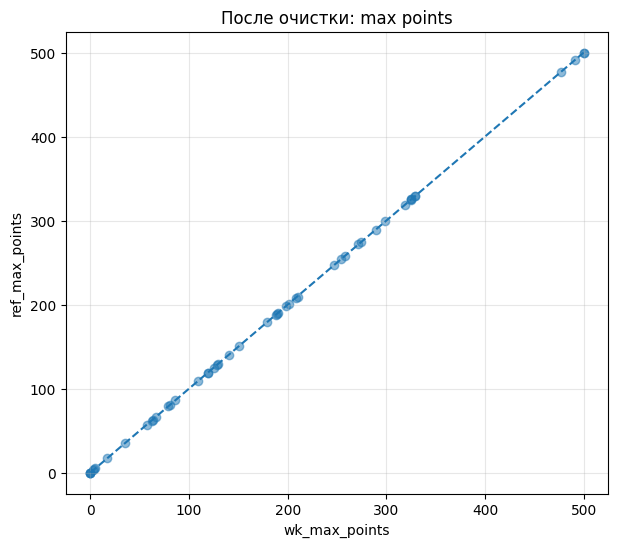

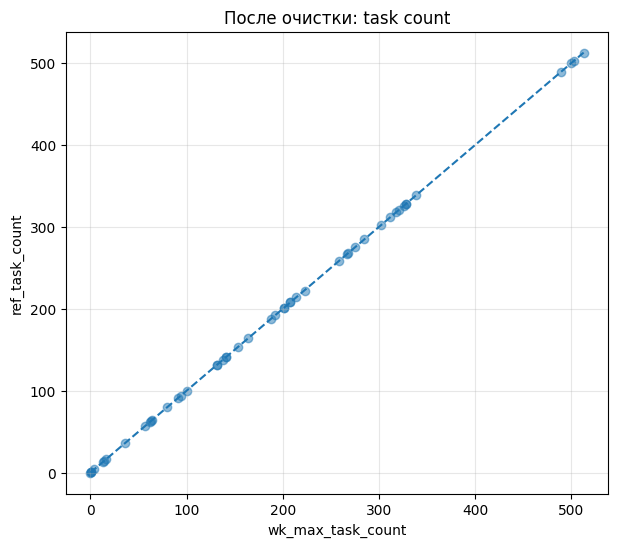

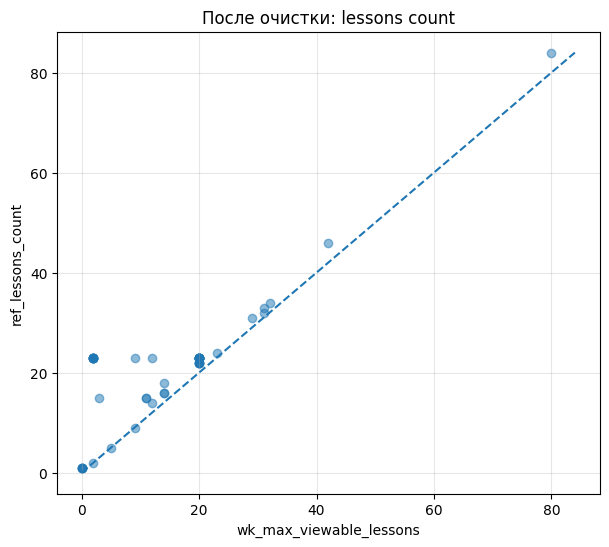

In [96]:
for x_col, y_col, title in [
    ("wk_max_points", "ref_max_points", "После очистки: max points"),
    ("wk_max_task_count", "ref_task_count", "После очистки: task count"),
    ("wk_max_viewable_lessons", "ref_lessons_count", "После очистки: lessons count"),
]:
    tmp = course_level_validation_clean_h.dropna(subset=[x_col, y_col]).copy()

    plt.figure(figsize=(7, 6))
    plt.scatter(tmp[x_col], tmp[y_col], alpha=0.5)
    mn = min(tmp[x_col].min(), tmp[y_col].min())
    mx = max(tmp[x_col].max(), tmp[y_col].max())
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

In [97]:
# Разность именно по числу уроков
course_level_validation_clean_h["diff_lessons_count"].value_counts(dropna=False).sort_index()

diff_lessons_count
-21.0     8
-14.0     1
-12.0     1
-11.0     1
-4.0      5
-3.0     12
-2.0     11
-1.0      7
 0.0      3
Name: count, dtype: Int64

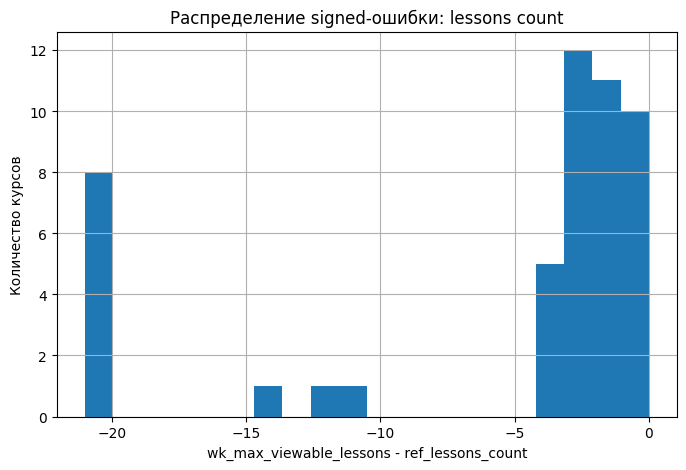

In [98]:
plt.figure(figsize=(8, 5))
course_level_validation_clean_h["diff_lessons_count"].dropna().hist(bins=20)
plt.title("Распределение signed-ошибки: lessons count")
plt.xlabel("wk_max_viewable_lessons - ref_lessons_count")
plt.ylabel("Количество курсов")
plt.show()

In [99]:
lessons_count_residuals = course_level_validation_clean_h[
    [
        "course_id",
        "wk_max_viewable_lessons",
        "ref_lessons_count",
        "diff_lessons_count",
        "abs_diff_lessons_count",
    ]
].sort_values("abs_diff_lessons_count", ascending=False)

display(lessons_count_residuals.head(20))

,course_id,wk_max_viewable_lessons,ref_lessons_count,diff_lessons_count,abs_diff_lessons_count
16,936,2.0,23,-21.0,21.0
20,945,2.0,23,-21.0,21.0
23,949,2.0,23,-21.0,21.0
22,948,2.0,23,-21.0,21.0
21,946,2.0,23,-21.0,21.0
18,942,2.0,23,-21.0,21.0
19,943,2.0,23,-21.0,21.0
17,937,2.0,23,-21.0,21.0
15,934,9.0,23,-14.0,14.0
44,1063,3.0,15,-12.0,12.0


#### Интерпретация расхождения по `lessons_count`

После очистки данных видно, что основное остаточное расхождение между `users_courses` и агрегатами из `lessons` связано не с баллами и не с числом заданий, а именно с числом уроков.

При этом расхождение по `lessons_count` выглядит не хаотическим, а систематическим:
- точки на scatter-графике располагаются близко к диагонали;
- у многих курсов наблюдается небольшой стабильный сдвиг;
- сильного случайного разброса нет.

Это позволяет предположить, что `wk_max_viewable_lessons` и `count(lessons)` не являются полностью тождественными величинами:
первое поле описывает максимальное число уроков, которые пользователь может пройти на курсе, а второе — число lesson-объектов в LMS.

Следовательно, небольшое систематическое расхождение по числу уроков не опровергает гипотезу о корректности merge с `lessons`, если по `wk_max_points` и `wk_max_task_count` согласованность остаётся высокой.

-----

#### 3.4.0 Финальная очистка `users_courses` и merge с `lessons`

После проверки гипотезы переходим к финальной подготовке `users_courses` для merge с course-level признаками из `lessons`.

На этом шаге:
- удаляем явно шумные курсы с очень малым числом записей и отсутствием корректного reference;
- удаляем строки, которые ранее были помечены как гарантированно плохие;
- заполняем пропуски в course-level полях значениями из `lessons`;
- если reference из `lessons` отсутствует, такие строки исключаем;
- после этого выполняем полноценный merge `users_courses` с агрегированными признаками из `lessons`.

Таким образом, итоговое объединение строится уже на очищенной и согласованной базе.

In [100]:
# ============================================================
# Явно шумные курсы
# ============================================================

manually_bad_courses = {953, 892, 956}

manual_bad_courses_stats = (
    dfs["users_courses"]
    .loc[dfs["users_courses"]["course_id"].isin(manually_bad_courses)]
    .groupby("course_id", dropna=False)
    .agg(
        total_rows=("course_id", "size"),
        na_wk_max_points=("wk_max_points", lambda s: s.isna().sum()),
        na_wk_max_task_count=("wk_max_task_count", lambda s: s.isna().sum()),
        na_wk_max_viewable_lessons=("wk_max_viewable_lessons", lambda s: s.isna().sum()),
    )
    .reset_index()
)

display(manual_bad_courses_stats)

,course_id,total_rows,na_wk_max_points,na_wk_max_task_count,na_wk_max_viewable_lessons
0,892,7,7,7,0
1,953,1,1,1,1
2,956,2,2,2,2


In [101]:
# ============================================================
# Финальная очистка users_courses
# ============================================================

users_courses_final = dfs["users_courses"].copy()

# 1) Удаляем явно шумные курсы
users_courses_final = users_courses_final[
    ~users_courses_final["course_id"].isin(manually_bad_courses)
].copy()

# 2) Удаляем гарантированно плохие строки
# Берём ключи строк из users_courses_with_canon_h
bad_row_keys = users_courses_with_canon_h.loc[
    users_courses_with_canon_h["is_guaranteed_bad_row"],
    ["course_id", "user_id"]
].drop_duplicates()

users_courses_final = users_courses_final.merge(
    bad_row_keys.assign(_drop_bad_row=True),
    on=["course_id", "user_id"],
    how="left"
)

users_courses_final = users_courses_final[
    users_courses_final["_drop_bad_row"] != True
].drop(columns="_drop_bad_row")

print("users_courses after removing manual bad courses and guaranteed bad rows:", users_courses_final.shape)

users_courses after removing manual bad courses and guaranteed bad rows: (262754, 12)


In [102]:
# ============================================================
# Добавляем reference из lessons
# ============================================================

users_courses_final = users_courses_final.merge(
    course_reference,
    on="course_id",
    how="left",
    validate="many_to_one"
)

display(
    users_courses_final[
        [
            "course_id",
            "wk_max_points",
            "wk_max_task_count",
            "wk_max_viewable_lessons",
            "ref_max_points",
            "ref_task_count",
            "ref_lessons_count",
        ]
    ].head()
)

,course_id,wk_max_points,wk_max_task_count,wk_max_viewable_lessons,ref_max_points,ref_task_count,ref_lessons_count
0,771,63.0,63.0,14.0,63.0,63.0,16
1,763,4.0,4.0,5.0,4.0,4.0,5
2,770,62.0,62.0,14.0,62.0,62.0,16
3,770,62.0,62.0,14.0,62.0,62.0,16
4,771,63.0,63.0,14.0,63.0,63.0,16


In [103]:
# ============================================================
# Заполнение NaN из lessons-reference
# ============================================================

users_courses_final["wk_max_points"] = users_courses_final["wk_max_points"].fillna(
    users_courses_final["ref_max_points"]
)

users_courses_final["wk_max_task_count"] = users_courses_final["wk_max_task_count"].fillna(
    users_courses_final["ref_task_count"]
)

users_courses_final["wk_max_viewable_lessons"] = users_courses_final["wk_max_viewable_lessons"].fillna(
    users_courses_final["ref_lessons_count"]
)

In [104]:
# ============================================================
#  Удаляем строки, где даже после lessons-reference
# не удалось восстановить ключевые course-level поля
# ============================================================

key_course_cols = [
    "wk_max_points",
    "wk_max_task_count",
    "wk_max_viewable_lessons",
]

rows_before_drop_no_reference = len(users_courses_final)

users_courses_final = users_courses_final.dropna(subset=key_course_cols).copy()

rows_after_drop_no_reference = len(users_courses_final)

print("Удалено строк без восстанавливаемого reference:", rows_before_drop_no_reference - rows_after_drop_no_reference)
print("users_courses_final shape:", users_courses_final.shape)

Удалено строк без восстанавливаемого reference: 0
users_courses_final shape: (262754, 15)


In [105]:
# ============================================================
#  Полноценный merge с агрегированными признаками lessons
# ============================================================

users_courses_final = users_courses_final.drop(
    columns=["ref_max_points", "ref_task_count", "ref_lessons_count"],
    errors="ignore"
)

users_courses_final = users_courses_final.merge(
    dfs["courses"],
    on="course_id",
    how="left",
    validate="many_to_one"
)

print("users_courses_final after lessons merge:", users_courses_final.shape)
display(users_courses_final.head())

users_courses_final after lessons merge: (262754, 33)


,user_id,course_id,created_at,updated_at,access_finished_at,wk_max_points,wk_max_viewable_lessons,wk_max_task_count,wk_officially_started_at,wk_course_completed_at,is_active,progress_pct,lessons_total_count,lessons_task_count_sum,lessons_task_count_mean,lessons_task_count_max,lessons_max_points_sum,lessons_max_points_mean,lessons_max_points_max,lessons_points_per_task_mean,lessons_video_duration_sum,lessons_video_duration_mean,lessons_video_duration_max,lessons_points_equal_task_share,lessons_with_number_share,lessons_conspect_expected_share,lessons_task_expected_share,lessons_tasks_observed_share,lessons_video_share,lessons_attendance_enabled_share,lessons_survival_share,lessons_scratch_share,lessons_task_flag_mismatch_share
0,718902,771,2025-10-14 14:55:00,2025-11-10 14:05:00,2026-04-14,63.0,14.0,63.0,NaT,NaT,True,71.59,16,63.0,3.9375,15.0,63.0,3.9375,15.0,1.0,127.0,9.071429,14.0,1.0,0.0,0.875,0.875,1.0,0.875,0.0,0.0,0.0,0.125
1,708314,763,2025-09-19 18:04:00,2025-10-02 15:12:00,2026-03-19,4.0,5.0,4.0,2025-09-19,NaT,True,58.25,5,4.0,2.0000,2.0,4.0,2.0000,2.0,1.0,20.0,6.666667,10.0,1.0,0.4,0.4,0.4,0.4,0.6,0.0,0.0,0.0,0.0
2,703125,770,2025-09-10 18:35:00,2025-10-06 09:26:00,2026-03-10,62.0,14.0,62.0,2025-09-10,NaT,True,0.00,16,62.0,3.8750,15.0,62.0,3.8750,15.0,1.0,140.0,10.000000,13.0,1.0,0.0,0.875,0.875,1.0,0.875,0.0,0.0,0.0,0.125
3,711827,770,2025-10-07 19:25:00,2025-11-04 10:14:00,2026-04-07,62.0,14.0,62.0,2025-10-07,NaT,True,89.56,16,62.0,3.8750,15.0,62.0,3.8750,15.0,1.0,140.0,10.000000,13.0,1.0,0.0,0.875,0.875,1.0,0.875,0.0,0.0,0.0,0.125
4,680366,771,2025-08-26 14:18:00,2025-09-09 08:44:00,2026-02-26,63.0,14.0,63.0,NaT,NaT,True,54.49,16,63.0,3.9375,15.0,63.0,3.9375,15.0,1.0,127.0,9.071429,14.0,1.0,0.0,0.875,0.875,1.0,0.875,0.0,0.0,0.0,0.125


In [106]:
# ============================================================
#  Контроль после merge
# ============================================================

final_na_check = users_courses_final[
    ["wk_max_points", "wk_max_task_count", "wk_max_viewable_lessons"]
].isna().sum()

display(final_na_check)

print("Уникальных course_id после финальной очистки:", users_courses_final["course_id"].nunique())
print("Уникальных user_id после финальной очистки:", users_courses_final["user_id"].nunique())

wk_max_points              0
wk_max_task_count          0
wk_max_viewable_lessons    0
dtype: int64

Уникальных course_id после финальной очистки: 79
Уникальных user_id после финальной очистки: 83175


In [107]:
# ============================================================
#  Сводка по финальной очистке users_courses
# ============================================================

users_courses_before_final = dfs["users_courses"].copy()
users_courses_after_final = users_courses_final.copy()

rows_before = len(users_courses_before_final)
rows_after = len(users_courses_after_final)
rows_removed = rows_before - rows_after
rows_removed_share = rows_removed / rows_before if rows_before > 0 else np.nan

courses_before = set(users_courses_before_final["course_id"].dropna().unique())
courses_after = set(users_courses_after_final["course_id"].dropna().unique())

removed_courses = sorted(courses_before - courses_after)

summary_final_cleaning = pd.DataFrame({
    "metric": [
        "rows_before",
        "rows_after",
        "rows_removed",
        "rows_removed_share",
        "n_courses_before",
        "n_courses_after",
        "n_courses_removed",
    ],
    "value": [
        rows_before,
        rows_after,
        rows_removed,
        rows_removed_share,
        len(courses_before),
        len(courses_after),
        len(removed_courses),
    ]
})

display(summary_final_cleaning)

print(f"Удалено строк: {rows_removed} ({rows_removed_share:.4%} от исходного users_courses)")
print(f"Удалено course_id целиком: {len(removed_courses)}")
print("Полностью исчезнувшие course_id:")
print(removed_courses)

,metric,value
0,rows_before,267206.000000
1,rows_after,262754.000000
2,rows_removed,4452.000000
3,rows_removed_share,0.016661
4,n_courses_before,82.000000
5,n_courses_after,79.000000
6,n_courses_removed,3.000000


Удалено строк: 4452 (1.6661% от исходного users_courses)
Удалено course_id целиком: 3
Полностью исчезнувшие course_id:
[np.int64(892), np.int64(953), np.int64(956)]


### Вывод по гипотезе 1

После очистки teacher-аккаунтов, удаления явно шумных курсов и гарантированно плохих строк, а также восстановления пропусков в course-level полях через `lessons`, основная таблица `users_courses` была приведена к согласованному виду.

Дальнейший merge с course-level признаками, построенными из `lessons`, можно считать обоснованным, потому что:
- по `wk_max_points` и `wk_max_task_count` согласованность с `lessons` высокая;
- расхождение по `wk_max_viewable_lessons` носит в основном систематический, а не хаотический характер;
- явный шум и невосстанавливаемые строки были исключены до финального merge.

Следовательно, гипотеза о корректности объединения `users_courses` с агрегированными признаками из `lessons` по `course_id` считается подтверждённой.

### Очистка словаря таблиц после безопасных merge

После того как признаки из `courses` и `lessons` уже перенесены в `users_courses`,
исходные таблицы можно убрать из `dfs`, чтобы:
- не дублировать информацию;
- не путаться в нескольких версиях одних и тех же признаков;
- упростить дальнейший анализ.

In [108]:
dfs["users_courses"] = users_courses_final.copy()

In [109]:
del dfs["courses"]
del dfs["lessons"]
del users_courses_final

In [110]:
dfs['users_courses'] = dfs['users_courses'].drop(columns=['lessons_max_points_sum', 'lessons_task_count_sum'])

In [111]:


objects_to_delete = [
    # промежуточные таблицы проверки гипотезы
    "users_courses_hypothesis",
    "course_sizes_hypothesis",
    "signature_counts_h",
    "signature_validation_h",
    "signature_validation_h_sorted",
    "canonical_signatures_h",
    "users_courses_with_canon_h",
    "anomaly_by_course_h",
    "users_courses_clean_h",
    "users_courses_clean_ref_h",
    "course_level_validation_clean_h",
    "hypothesis_1_metrics_clean_h",

    # reference и служебные таблицы, если они больше не нужны
    "course_reference",
    "bad_row_keys",
    "small_courses",
    "valid_course_ids_by_size",
    "soft_alternative_courses_h",

    # отладочные таблицы
    "manual_bad_courses_stats",
    "summary_final_cleaning",
    "removed_courses_stats",
    "problem_courses_row_stats",
    "problem_courses_anomaly_stats",
    "problem_course_signatures",
    "lessons_count_residuals",
    "summary_for_report",
    "reason_compare",
    "reason_compare_plot",

    # детальные разборы отдельных курсов
    "course_1103_rows",
    "course_1103_signatures",
    "course_1103_signature_counts",
    "course_1103_time",
    "course_1103_pivot",
    "problem_lesson_count_courses",
]

deleted_objects = []
not_found_objects = []

for name in objects_to_delete:
    if name in globals():
        del globals()[name]
        deleted_objects.append(name)
    else:
        not_found_objects.append(name)

gc.collect()

print(f"Удалено объектов: {len(deleted_objects)}")
print("Удалённые объекты:")
print(deleted_objects)

if not_found_objects:
    print("\nНе найдены в globals():")
    print(not_found_objects)

Удалено объектов: 20
Удалённые объекты:
['users_courses_hypothesis', 'course_sizes_hypothesis', 'signature_counts_h', 'signature_validation_h', 'signature_validation_h_sorted', 'canonical_signatures_h', 'users_courses_with_canon_h', 'anomaly_by_course_h', 'users_courses_clean_h', 'users_courses_clean_ref_h', 'course_level_validation_clean_h', 'hypothesis_1_metrics_clean_h', 'course_reference', 'bad_row_keys', 'small_courses', 'valid_course_ids_by_size', 'soft_alternative_courses_h', 'manual_bad_courses_stats', 'summary_final_cleaning', 'lessons_count_residuals']

Не найдены в globals():
['removed_courses_stats', 'problem_courses_row_stats', 'problem_courses_anomaly_stats', 'problem_course_signatures', 'summary_for_report', 'reason_compare', 'reason_compare_plot', 'course_1103_rows', 'course_1103_signatures', 'course_1103_signature_counts', 'course_1103_time', 'course_1103_pivot', 'problem_lesson_count_courses']


### Гипотеза 2. `user_activity_histories` можно исключить из основного пайплайна

#### Почему вообще появилась эта гипотеза

По описанию датасета `user_activity_histories` содержит только три типа действий:
- `visit_video`
- `show_conspect`
- `visit_translation`

и хранит их как `user_lesson_id + action + created_at`. При этом на `user_id` и дальше на course-level нужно выходить через `user_lesson_id`. В `wk_users_courses_actions` уже лежит более широкий журнал course-level активности: кроме `visit_video` и `visit_translation`, там есть `start_training`, `user_answer`, `visit_preparation_material` и другие действия. Это делает `wk_users_courses_actions` потенциально более полезным источником поведенческих признаков. :contentReference[oaicite:0]{index=0} :contentReference[oaicite:1]{index=1}

#### Что именно мы проверяем

На текущем экспорте мы **не можем** строго сопоставить события по пользователю и уроку, потому что в `user_activity_histories` ключом выступает `user_lesson_id`, а корректного моста до `user_id / lesson_id / users_course_id` в основном пайплайне нет. Поэтому здесь мы проверяем более узкую, но всё ещё строгую версию гипотезы:

> если взять одинаковый `created_at` и одинаковый тип действия, насколько часто событие из `user_activity_histories` уже представлено в `wk_users_courses_actions`.

То есть сравнение выполняется по паре:

- `created_at`
- `action`

а не по полному event-key пользователя.

#### Как именно считается покрытие

Для каждой пары сопоставляемых действий:
- `visit_video` ↔ `visit_video`
- `visit_translation` ↔ `visit_translation`
- `show_conspect` ↔ `visit_preparation_material`

мы агрегируем обе таблицы по точному timestamp `created_at` и считаем число событий в каждой таблице для каждого момента времени.

Далее для каждого timestamp считаем:


$ covered count(t)= \min(count_{UAH}(t),\ count_{WKA}(t)) $


где:
- $count_{UAH}(t)$ — сколько событий данного типа было в `user_activity_histories` в момент времени \(t\),
- $count_{WKA}(t)$ — сколько соответствующих событий было в `wk_users_courses_actions` в тот же момент времени.

Итоговая доля покрытия считается как


$coverage\ ratio=\frac{\sum_t covered\_count(t)}{\sum_t count_{UAH}(t)}$


Таким образом, мы измеряем не просто сходство распределений, а именно **долю событий из `user_activity_histories`, которые имеют точное совпадение по времени и типу действия в `wk_users_courses_actions`**.

#### Почему мы дополнительно смотрим покрытие после старта `wk_users_courses_actions`

В примере данных видно, что `wk_users_courses_actions` начинает фиксироваться как минимум с февраля 2025 года, и уже в ранних строках там есть `visit_video` и `visit_preparation_material` с точными timestamp. Поэтому отдельно важно смотреть покрытие **после первой записи в `wk_users_courses_actions`**, а не смешивать его с периодом, когда этот журнал ещё мог не вестись. :contentReference[oaicite:2]{index=2} :contentReference[oaicite:3]{index=3}

#### Что означает кумулятивное покрытие

Кумулятивное покрытие показывает не долю совпадений в один конкретный день, а накопленную долю покрытых событий от начала рассматриваемого периода до текущей даты:


$coverage\_ratio\_cum(t)=\frac{\sum_{\tau \le t} covered\_count(\tau)}{\sum_{\tau \le t} count_{UAH}(\tau)}$


Эта метрика нужна, чтобы ответить на вопрос:

> с какого момента большая часть событий из `user_activity_histories` уже дублируется в `wk_users_courses_actions`.



In [113]:
# ============================================================
# Восстановление типов действий из one-hot флагов
# ============================================================

uah = dfs["user_activity_histories"].copy()
wka = dfs["wk_users_courses_actions"].copy()

# user_activity_histories
uah["ua_action"] = pd.NA
uah.loc[uah["is_visit_video"], "ua_action"] = "visit_video"
uah.loc[uah["is_visit_translation"], "ua_action"] = "visit_translation"
uah.loc[uah["is_show_conspect"], "ua_action"] = "show_conspect"

# wk_users_courses_actions
wka["wka_action"] = pd.NA
wka.loc[wka["is_visit_video"], "wka_action"] = "visit_video"
wka.loc[wka["is_visit_translation"], "wka_action"] = "visit_translation"
wka.loc[wka["is_show_conspect"], "wka_action"] = "visit_preparation_material"
wka.loc[wka["is_start_training"], "wka_action"] = "start_training"
wka.loc[wka["is_user_answer"], "wka_action"] = "user_answer"
wka.loc[wka["is_scratch_playground_visited"], "wka_action"] = "scratch_playground_visited"

print("UAH actions:")
display(uah["ua_action"].value_counts(dropna=False).rename("count").to_frame())

print("WKA actions:")
display(wka["wka_action"].value_counts(dropna=False).rename("count").to_frame())

UAH actions:


,count
ua_action,
visit_video,2642950
show_conspect,278340
visit_translation,109847


WKA actions:


,count
wka_action,
user_answer,9503944
visit_video,2557977
start_training,470267
visit_translation,93836
visit_preparation_material,7658
scratch_playground_visited,2


Рассмотрим временные рамки, насколько логи по wk_users_courses_actions появляются позже чем user_activity_histories

In [119]:
# ============================================================
# Первые и последние даты появления аналогичных действий
# ============================================================

action_map_h2 = {
    "visit_video": ["visit_video"],
    "visit_translation": ["visit_translation"],
    "show_conspect": ["visit_preparation_material"],
}

rows = []

for ua_action, mapped_wka_actions in action_map_h2.items():
    ua_mask = uah["ua_action"].isin([ua_action])
    wka_mask = wka["wka_action"].isin(mapped_wka_actions)

    ua_first = uah.loc[ua_mask, "created_at"].min()
    ua_last = uah.loc[ua_mask, "created_at"].max()

    wka_first = wka.loc[wka_mask, "created_at"].min()
    wka_last = wka.loc[wka_mask, "created_at"].max()

    rows.append({
        "ua_action": ua_action,
        "mapped_wka_actions": ", ".join(mapped_wka_actions),

        "ua_first_at": ua_first,
        "ua_last_at": ua_last,

        "mapped_wka_first_at": wka_first,
        "mapped_wka_last_at": wka_last,

        "delta_days_first_wka_minus_ua": (
            (wka_first - ua_first).days
            if pd.notna(ua_first) and pd.notna(wka_first)
            else np.nan
        ),

        "delta_days_last_wka_minus_ua": (
            (wka_last - ua_last).days
            if pd.notna(ua_last) and pd.notna(wka_last)
            else np.nan
        )
    })

hypothesis_2_time_bounds = (
    pd.DataFrame(rows)
    .sort_values("ua_action")
    .reset_index(drop=True)
)

display(hypothesis_2_time_bounds)

,ua_action,mapped_wka_actions,ua_first_at,ua_last_at,mapped_wka_first_at,mapped_wka_last_at,delta_days_first_wka_minus_ua,delta_days_last_wka_minus_ua
0,show_conspect,visit_preparation_material,2020-12-03 21:28:00,2026-03-31 15:16:00,2025-02-19 18:00:00,2026-03-13 06:21:00,1538,-19
1,visit_translation,visit_translation,2020-11-25 13:36:00,2026-03-31 13:57:00,2025-03-06 10:13:00,2026-03-31 13:55:00,1561,-1
2,visit_video,visit_video,2020-12-03 21:28:00,2026-03-31 15:20:00,2025-02-17 11:35:00,2026-03-31 14:12:00,1536,-1


изучим корреляцию кол-ва действий в день, заданных в двух таблицах

In [120]:
# ============================================================
# Сравнение временной динамики по дням
# ============================================================

def build_daily_series(df: pd.DataFrame, action_col: str, actions) -> pd.DataFrame:
    if isinstance(actions, str):
        actions = [actions]

    tmp = df.loc[df[action_col].isin(actions), ["created_at"]].copy()
    tmp["date"] = tmp["created_at"].dt.floor("D")

    out = (
        tmp.groupby("date")
        .size()
        .rename("count")
        .reset_index()
    )
    return out


daily_compare_parts = []
daily_corr_rows = []

for ua_action, mapped_wka_actions in action_map_h2.items():
    ua_daily = build_daily_series(uah, "ua_action", ua_action).rename(columns={"count": "ua_count"})
    wka_daily = build_daily_series(wka, "wka_action", mapped_wka_actions).rename(columns={"count": "wka_count"})

    cmp = ua_daily.merge(wka_daily, on="date", how="outer").sort_values("date")
    cmp["ua_count"] = cmp["ua_count"].fillna(0)
    cmp["wka_count"] = cmp["wka_count"].fillna(0)
    cmp["ua_action"] = ua_action
    cmp["mapped_wka_actions"] = ", ".join(mapped_wka_actions)

    corr = cmp["ua_count"].corr(cmp["wka_count"]) if len(cmp) > 1 else np.nan

    daily_corr_rows.append({
        "ua_action": ua_action,
        "mapped_wka_actions": ", ".join(mapped_wka_actions),
        "daily_corr": corr,
        "ua_total": cmp["ua_count"].sum(),
        "wka_total": cmp["wka_count"].sum(),
        "wka_to_ua_ratio": (
            cmp["wka_count"].sum() / cmp["ua_count"].sum()
            if cmp["ua_count"].sum() > 0 else np.nan
        )
    })

    daily_compare_parts.append(cmp)

hypothesis_2_daily_compare = pd.concat(daily_compare_parts, ignore_index=True)
hypothesis_2_daily_corr = (
    pd.DataFrame(daily_corr_rows)
    .sort_values("ua_action")
    .reset_index(drop=True)
)

display(hypothesis_2_daily_corr)

,ua_action,mapped_wka_actions,daily_corr,ua_total,wka_total,wka_to_ua_ratio
0,show_conspect,visit_preparation_material,-0.126329,278340,7658.0,0.027513
1,visit_translation,visit_translation,0.987900,109847,93836.0,0.854243
2,visit_video,visit_video,0.999914,2642950,2557977.0,0.967849


In [121]:
# ============================================================
# Помесячная динамика отношения объёмов
# ============================================================

monthly_compare_parts = []

for ua_action, mapped_wka_actions in action_map_h2.items():
    ua_monthly = (
        uah.loc[uah["ua_action"] == ua_action, ["created_at"]]
        .assign(month=lambda x: x["created_at"].dt.to_period("M").dt.to_timestamp())
        .groupby("month")
        .size()
        .rename("ua_count")
        .reset_index()
    )

    wka_monthly = (
        wka.loc[wka["wka_action"].isin(mapped_wka_actions), ["created_at"]]
        .assign(month=lambda x: x["created_at"].dt.to_period("M").dt.to_timestamp())
        .groupby("month")
        .size()
        .rename("wka_count")
        .reset_index()
    )

    cmp = ua_monthly.merge(wka_monthly, on="month", how="outer").sort_values("month")
    cmp["ua_count"] = cmp["ua_count"].fillna(0)
    cmp["wka_count"] = cmp["wka_count"].fillna(0)
    cmp["wka_to_ua_ratio"] = np.where(cmp["ua_count"] > 0, cmp["wka_count"] / cmp["ua_count"], np.nan)
    cmp["ua_action"] = ua_action
    cmp["mapped_wka_actions"] = ", ".join(mapped_wka_actions)

    monthly_compare_parts.append(cmp)

hypothesis_2_monthly_compare = pd.concat(monthly_compare_parts, ignore_index=True)

display(hypothesis_2_monthly_compare)

,month,ua_count,wka_count,wka_to_ua_ratio,ua_action,mapped_wka_actions
0,2020-12-01,131,0.0,0.000000,visit_video,visit_video
1,2021-01-01,109,0.0,0.000000,visit_video,visit_video
2,2021-02-01,43,0.0,0.000000,visit_video,visit_video
3,2021-03-01,67,0.0,0.000000,visit_video,visit_video
4,2021-04-01,28,0.0,0.000000,visit_video,visit_video
5,2021-05-01,6,0.0,0.000000,visit_video,visit_video
6,2021-06-01,50,0.0,0.000000,visit_video,visit_video
7,2021-07-01,27,0.0,0.000000,visit_video,visit_video
8,2021-10-01,13,0.0,0.000000,visit_video,visit_video
9,2021-11-01,35,0.0,0.000000,visit_video,visit_video


In [117]:
# ============================================================
# Поиск месяца, с которого WKA начинает устойчиво покрывать UAH
# ============================================================

def detect_stable_onset(monthly_df: pd.DataFrame, min_ua_count: int = 100, ratio_threshold: float = 0.8, consecutive_months: int = 2):
    df = monthly_df.loc[monthly_df["ua_count"] >= min_ua_count].sort_values("month").reset_index(drop=True)
    if df.empty:
        return pd.NaT

    good = df["wka_to_ua_ratio"] >= ratio_threshold
    streak = 0
    start_month = pd.NaT

    for i, is_good in enumerate(good):
        if is_good:
            streak += 1
            if streak == 1:
                start_month = df.loc[i, "month"]
            if streak >= consecutive_months:
                return start_month
        else:
            streak = 0
            start_month = pd.NaT

    return pd.NaT


onset_rows = []

for ua_action in action_map_h2.keys():
    sub = hypothesis_2_monthly_compare.loc[hypothesis_2_monthly_compare["ua_action"] == ua_action].copy()

    onset_rows.append({
        "ua_action": ua_action,
        "mapped_wka_actions": sub["mapped_wka_actions"].iloc[0] if len(sub) > 0 else pd.NA,
        "stable_onset_month": detect_stable_onset(sub)
    })

hypothesis_2_onset = pd.DataFrame(onset_rows)
display(hypothesis_2_onset)

,ua_action,mapped_wka_actions,stable_onset_month
0,visit_video,visit_video,2025-05-01
1,visit_translation,visit_translation,2025-10-01
2,show_conspect,visit_preparation_material,2025-04-01


Теперь более строго изучим корреляцию

In [122]:
# ============================================================
# H2: строгое покрытие по (created_at, action) с учётом кратности
# ============================================================


overlap_rows = []

for ua_action, mapped_wka_actions in action_map_h2.items():
    u_sub = uah.loc[uah["ua_action"] == ua_action, ["created_at"]].copy()
    w_sub = wka.loc[wka["wka_action"].isin(mapped_wka_actions), ["created_at"]].copy()

    u_counts = (
        u_sub.groupby("created_at")
        .size()
        .rename("uah_count")
        .reset_index()
    )

    w_counts = (
        w_sub.groupby("created_at")
        .size()
        .rename("wka_count")
        .reset_index()
    )

    cmp = u_counts.merge(w_counts, on="created_at", how="outer").sort_values("created_at")
    cmp["uah_count"] = cmp["uah_count"].fillna(0).astype(int)
    cmp["wka_count"] = cmp["wka_count"].fillna(0).astype(int)
    cmp["covered_count"] = np.minimum(cmp["uah_count"], cmp["wka_count"])
    cmp["ua_action"] = ua_action
    cmp["mapped_wka_actions"] = ", ".join(mapped_wka_actions)

    overlap_rows.append({
        "ua_action": ua_action,
        "mapped_wka_actions": ", ".join(mapped_wka_actions),
        "uah_total_events": cmp["uah_count"].sum(),
        "wka_total_events": cmp["wka_count"].sum(),
        "covered_events_exact_ts": cmp["covered_count"].sum(),
        "coverage_ratio_exact_ts": (
            cmp["covered_count"].sum() / cmp["uah_count"].sum()
            if cmp["uah_count"].sum() > 0 else np.nan
        ),
    })

hypothesis_2_exact_overlap = (
    pd.DataFrame(overlap_rows)
    .sort_values("ua_action")
    .reset_index(drop=True)
)

display(hypothesis_2_exact_overlap)

,ua_action,mapped_wka_actions,uah_total_events,wka_total_events,covered_events_exact_ts,coverage_ratio_exact_ts
0,show_conspect,visit_preparation_material,278340,7658,986,0.003542
1,visit_translation,visit_translation,109847,93836,93833,0.854215
2,visit_video,visit_video,2642950,2557977,2557949,0.967839


In [123]:
# ============================================================
# H2: покрытие после первой записи в WKA
# ============================================================

wka_first_global_dt = wka["created_at"].min()
print("Первая запись в wk_users_courses_actions:", wka_first_global_dt)

overlap_after_start_rows = []

for ua_action, mapped_wka_actions in action_map_h2.items():
    u_sub = uah.loc[
        (uah["ua_action"] == ua_action) &
        (uah["created_at"] >= wka_first_global_dt),
        ["created_at"]
    ].copy()

    w_sub = wka.loc[
        (wka["wka_action"].isin(mapped_wka_actions)) &
        (wka["created_at"] >= wka_first_global_dt),
        ["created_at"]
    ].copy()

    u_counts = (
        u_sub.groupby("created_at")
        .size()
        .rename("uah_count")
        .reset_index()
    )

    w_counts = (
        w_sub.groupby("created_at")
        .size()
        .rename("wka_count")
        .reset_index()
    )

    cmp = u_counts.merge(w_counts, on="created_at", how="outer").sort_values("created_at")
    cmp["uah_count"] = cmp["uah_count"].fillna(0).astype(int)
    cmp["wka_count"] = cmp["wka_count"].fillna(0).astype(int)
    cmp["covered_count"] = np.minimum(cmp["uah_count"], cmp["wka_count"])

    overlap_after_start_rows.append({
        "ua_action": ua_action,
        "mapped_wka_actions": ", ".join(mapped_wka_actions),
        "uah_total_after_wka_start": cmp["uah_count"].sum(),
        "wka_total_after_wka_start": cmp["wka_count"].sum(),
        "covered_after_wka_start": cmp["covered_count"].sum(),
        "coverage_ratio_after_wka_start": (
            cmp["covered_count"].sum() / cmp["uah_count"].sum()
            if cmp["uah_count"].sum() > 0 else np.nan
        ),
    })

hypothesis_2_overlap_after_start = (
    pd.DataFrame(overlap_after_start_rows)
    .sort_values("ua_action")
    .reset_index(drop=True)
)

display(hypothesis_2_overlap_after_start)

Первая запись в wk_users_courses_actions: 2025-02-17 11:35:00


,ua_action,mapped_wka_actions,uah_total_after_wka_start,wka_total_after_wka_start,covered_after_wka_start,coverage_ratio_after_wka_start
0,show_conspect,visit_preparation_material,276219,7658,986,0.003570
1,visit_translation,visit_translation,109720,93836,93833,0.855204
2,visit_video,visit_video,2622743,2557977,2557949,0.975295


In [129]:
# ============================================================
# H2: подневная доля покрытия после старта WKA
# ============================================================

daily_coverage_parts = []

for ua_action, mapped_wka_actions in action_map_h2.items():
    u_sub = uah.loc[
        (uah["ua_action"] == ua_action) &
        (uah["created_at"] >= wka_first_global_dt),
        ["created_at"]
    ].copy()

    w_sub = wka.loc[
        (wka["wka_action"].isin(mapped_wka_actions)) &
        (wka["created_at"] >= wka_first_global_dt),
        ["created_at"]
    ].copy()

    # считаем по точному timestamp, потом агрегируем в день
    u_counts = (
        u_sub.groupby("created_at")
        .size()
        .rename("uah_count")
        .reset_index()
    )

    w_counts = (
        w_sub.groupby("created_at")
        .size()
        .rename("wka_count")
        .reset_index()
    )

    cmp = u_counts.merge(w_counts, on="created_at", how="outer").sort_values("created_at")
    cmp["uah_count"] = cmp["uah_count"].fillna(0).astype(int)
    cmp["wka_count"] = cmp["wka_count"].fillna(0).astype(int)
    cmp["covered_count"] = np.minimum(cmp["uah_count"], cmp["wka_count"])
    cmp["date"] = cmp["created_at"].dt.floor("D")

    daily = (
        cmp.groupby("date")
        .agg(
            uah_count=("uah_count", "sum"),
            wka_count=("wka_count", "sum"),
            covered_count=("covered_count", "sum"),
        )
        .reset_index()
        .sort_values("date")
    )

    daily["coverage_ratio"] = np.where(
        daily["uah_count"] > 0,
        daily["covered_count"] / daily["uah_count"],
        np.nan
    )
    daily["ua_action"] = ua_action
    daily["mapped_wka_actions"] = ", ".join(mapped_wka_actions)

    daily_coverage_parts.append(daily)

hypothesis_2_daily_coverage = pd.concat(daily_coverage_parts, ignore_index=True)


display(
    hypothesis_2_daily_coverage.style
    .set_table_attributes('style="display:block; max-height:400px; overflow-y:auto; overflow-x:auto;"')
)
#display(hypothesis_2_daily_coverage)

,date,uah_count,wka_count,covered_count,coverage_ratio,ua_action,mapped_wka_actions
0,2025-02-17 00:00:00,6,5,5,0.833333,visit_video,visit_video
1,2025-02-19 00:00:00,27,12,12,0.444444,visit_video,visit_video
2,2025-02-20 00:00:00,208,128,128,0.615385,visit_video,visit_video
3,2025-02-21 00:00:00,145,27,27,0.186207,visit_video,visit_video
4,2025-02-22 00:00:00,78,49,49,0.628205,visit_video,visit_video
5,2025-02-23 00:00:00,39,30,30,0.769231,visit_video,visit_video
6,2025-02-24 00:00:00,315,239,239,0.758730,visit_video,visit_video
7,2025-02-25 00:00:00,391,312,312,0.797954,visit_video,visit_video
8,2025-02-26 00:00:00,403,329,329,0.816377,visit_video,visit_video
9,2025-02-27 00:00:00,183,137,137,0.748634,visit_video,visit_video


In [125]:
# ============================================================
# H2: помесячная доля покрытия после старта WKA
# ============================================================

monthly_coverage_parts = []

for ua_action, mapped_wka_actions in action_map_h2.items():
    sub = hypothesis_2_daily_coverage.loc[
        hypothesis_2_daily_coverage["ua_action"] == ua_action
    ].copy()

    sub["month"] = sub["date"].dt.to_period("M").dt.to_timestamp()

    monthly = (
        sub.groupby("month")
        .agg(
            uah_count=("uah_count", "sum"),
            wka_count=("wka_count", "sum"),
            covered_count=("covered_count", "sum"),
        )
        .reset_index()
        .sort_values("month")
    )

    monthly["coverage_ratio"] = np.where(
        monthly["uah_count"] > 0,
        monthly["covered_count"] / monthly["uah_count"],
        np.nan
    )
    monthly["ua_action"] = ua_action
    monthly["mapped_wka_actions"] = ", ".join(mapped_wka_actions)

    monthly_coverage_parts.append(monthly)

hypothesis_2_monthly_coverage = pd.concat(monthly_coverage_parts, ignore_index=True)
display(hypothesis_2_monthly_coverage)

,month,uah_count,wka_count,covered_count,coverage_ratio,ua_action,mapped_wka_actions
0,2025-02-01,2398,1785,1785,0.744370,visit_video,visit_video
1,2025-03-01,30754,21779,21779,0.708168,visit_video,visit_video
2,2025-04-01,29792,23744,23744,0.796992,visit_video,visit_video
3,2025-05-01,20030,17124,17124,0.854918,visit_video,visit_video
4,2025-06-01,115159,107216,107216,0.931026,visit_video,visit_video
5,2025-07-01,73637,72599,72597,0.985877,visit_video,visit_video
6,2025-08-01,75277,75022,75022,0.996613,visit_video,visit_video
7,2025-09-01,159046,153867,153863,0.967412,visit_video,visit_video
8,2025-10-01,252167,242009,242006,0.959705,visit_video,visit_video
9,2025-11-01,834177,825410,825407,0.989487,visit_video,visit_video


In [128]:
# ============================================================
# H2: кумулятивное покрытие после старта WKA
# ============================================================

cumulative_coverage_parts = []

for ua_action, mapped_wka_actions in action_map_h2.items():
    sub = hypothesis_2_daily_coverage.loc[
        hypothesis_2_daily_coverage["ua_action"] == ua_action
    ].copy().sort_values("date")

    sub["uah_count_cum"] = sub["uah_count"].cumsum()
    sub["covered_count_cum"] = sub["covered_count"].cumsum()

    sub["coverage_ratio_cum"] = np.where(
        sub["uah_count_cum"] > 0,
        sub["covered_count_cum"] / sub["uah_count_cum"],
        np.nan
    )

    cumulative_coverage_parts.append(sub)

hypothesis_2_cumulative_coverage = pd.concat(cumulative_coverage_parts, ignore_index=True)



display(
    hypothesis_2_cumulative_coverage.style
    .set_table_attributes('style="display:block; max-height:400px; overflow-y:auto; overflow-x:auto;"')
)
#display(hypothesis_2_cumulative_coverage)

,date,uah_count,wka_count,covered_count,coverage_ratio,ua_action,mapped_wka_actions,uah_count_cum,covered_count_cum,coverage_ratio_cum
0,2025-02-17 00:00:00,6,5,5,0.833333,visit_video,visit_video,6,5,0.833333
1,2025-02-19 00:00:00,27,12,12,0.444444,visit_video,visit_video,33,17,0.515152
2,2025-02-20 00:00:00,208,128,128,0.615385,visit_video,visit_video,241,145,0.601660
3,2025-02-21 00:00:00,145,27,27,0.186207,visit_video,visit_video,386,172,0.445596
4,2025-02-22 00:00:00,78,49,49,0.628205,visit_video,visit_video,464,221,0.476293
5,2025-02-23 00:00:00,39,30,30,0.769231,visit_video,visit_video,503,251,0.499006
6,2025-02-24 00:00:00,315,239,239,0.758730,visit_video,visit_video,818,490,0.599022
7,2025-02-25 00:00:00,391,312,312,0.797954,visit_video,visit_video,1209,802,0.663358
8,2025-02-26 00:00:00,403,329,329,0.816377,visit_video,visit_video,1612,1131,0.701613
9,2025-02-27 00:00:00,183,137,137,0.748634,visit_video,visit_video,1795,1268,0.706407


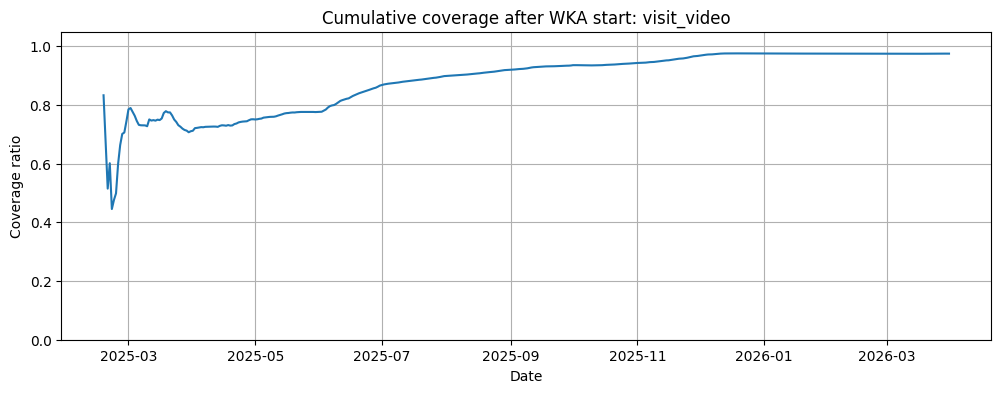

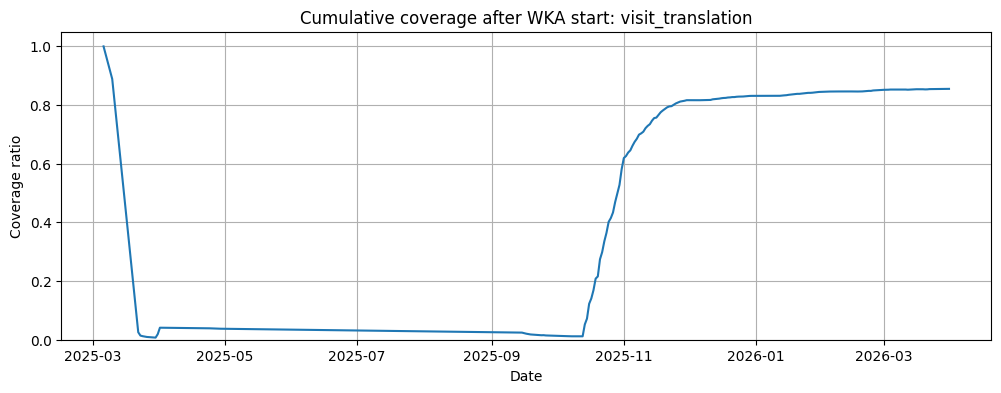

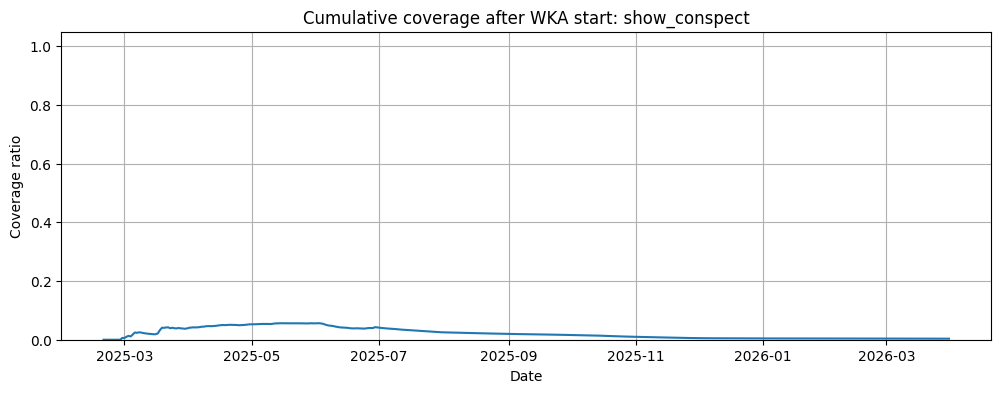

In [127]:
# ============================================================
# H2: график кумулятивного покрытия
# ============================================================

import matplotlib.pyplot as plt

for ua_action in hypothesis_2_cumulative_coverage["ua_action"].dropna().unique():
    sub = hypothesis_2_cumulative_coverage.loc[
        hypothesis_2_cumulative_coverage["ua_action"] == ua_action
    ].copy().sort_values("date")

    plt.figure(figsize=(12, 4))
    plt.plot(sub["date"], sub["coverage_ratio_cum"])
    plt.title(f"Cumulative coverage after WKA start: {ua_action}")
    plt.xlabel("Date")
    plt.ylabel("Coverage ratio")
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.show()

#### Результат проверки гипотезы

Проверка показала, что после начала заполнения `wk_users_courses_actions` для действий, связанных с просмотром контента, наблюдается очень высокое покрытие:
- для `visit_video` большая доля событий из `user_activity_histories` имеет точные совпадения в `wk_users_courses_actions`;
- для `visit_translation` наблюдается аналогичная картина;
- начиная с некоторого периода покрытие для этих действий стабильно превышает **90%**.

Это означает, что для видео и трансляций `wk_users_courses_actions` фактически берет на себя роль основного журнала событий, а `user_activity_histories` начинает дублировать уже имеющуюся информацию.

#### Финальный вывод по гипотезе 2

Гипотеза **подтверждается частично, но достаточно сильно для feature engineering**:

1. `user_activity_histories` структурно плохо встраивается в основной пайплайн из-за отсутствующего bridge-key;
2. для ключевых действий просмотра контента (`visit_video`, `visit_translation`) после старта `wk_users_courses_actions` наблюдается очень высокое покрытие, местами выше 90%;
3. `wk_users_courses_actions` при этом содержательно богаче, потому что хранит не только просмотр контента, но и ответы, запуск тренингов и другие course-level события.

Следовательно, `user_activity_histories` не является полным дублем `wk_users_courses_actions`, но для baseline-пайплайна её можно исключить как **структурно неудобную и в значительной степени избыточную**. Это согласуется с постановкой кейса, где акцент сделан на поиске интерпретируемых поведенческих паттернов и на создании информативных признаков из LMS-логов. :contentReference[oaicite:4]{index=4} :contentReference[oaicite:5]{index=5}

### Гипотеза 3. Агрегированная по `user_id` информация из `wk_media_view_sessions` корректно присоединяется к `users`

Таблица `wk_media_view_sessions` хранит сессии просмотра медиа-контента внутри LMS. По описанию датасета ключ `viewer_id` в этой таблице соответствует `id` пользователя из `users`, а сама таблица содержит event-level информацию: тип контента, число сегментов, число просмотренных сегментов и время начала просмотра. :contentReference[oaicite:0]{index=0}

Следовательно, напрямую присоединять `wk_media_view_sessions` к `users` нельзя, так как один пользователь может иметь много сессий просмотра. Однако после агрегации `wk_media_view_sessions` до уровня `viewer_id -> user_id` таблица должна корректно джойниться к `users` через `left join`.

Что проверяем:
1. корректно ли сопоставляются ключи `viewer_id` и `user_id`;
2. есть ли среди пользователей из `users` те, у кого вообще есть записи в `wk_media_view_sessions`;
3. после агрегации до user-level можно ли без раздувания строк присоединить media-признаки к `users`.

In [130]:
# ============================================================
# Гипотеза 3: проверка ключей users <-> wk_media_view_sessions
# ============================================================

users_df = dfs["users"].copy()
media_df = dfs["wk_media_view_sessions"].copy()

# Приводим ключи к единому типу
users_df["user_id"] = users_df["user_id"].astype("string")
media_df["viewer_id"] = media_df["viewer_id"].astype("string")

users_ids = set(users_df["user_id"].dropna().unique())
media_ids = set(media_df["viewer_id"].dropna().unique())

h3_key_check = pd.DataFrame([
    {"metric": "users_rows", "value": len(users_df)},
    {"metric": "users_unique_ids", "value": users_df["user_id"].nunique(dropna=True)},
    {"metric": "media_rows", "value": len(media_df)},
    {"metric": "media_unique_viewers", "value": media_df["viewer_id"].nunique(dropna=True)},
    {"metric": "viewer_ids_present_in_users", "value": len(media_ids & users_ids)},
    {"metric": "viewer_ids_absent_in_users", "value": len(media_ids - users_ids)},
    {"metric": "users_with_any_media", "value": len(users_ids & media_ids)},
    {"metric": "users_without_media", "value": len(users_ids - media_ids)},
    {"metric": "share_users_with_any_media", "value": len(users_ids & media_ids) / len(users_ids) if len(users_ids) > 0 else np.nan},
])

display(h3_key_check)

,metric,value
0,users_rows,90647.000000
1,users_unique_ids,90647.000000
2,media_rows,852358.000000
3,media_unique_viewers,45096.000000
4,viewer_ids_present_in_users,44053.000000
5,viewer_ids_absent_in_users,1043.000000
6,users_with_any_media,44053.000000
7,users_without_media,46594.000000
8,share_users_with_any_media,0.485984


#### Промежуточный вывод по гипотезе 3

Проверка ключей показала, что таблица `wk_media_view_sessions` почти полностью согласуется с `users` по связке `viewer_id -> user_id`.

Из `45,096` уникальных `viewer_id` в `wk_media_view_sessions`:
- `44,053` присутствуют в `users`;
- только `1,043` отсутствуют в `users`.

Это составляет около **2.31%** от числа уникальных `viewer_id` в `wk_media_view_sessions`, то есть подавляющее большинство медиа-сессий можно корректно сопоставить с пользователями.

Следовательно, после агрегации `wk_media_view_sessions` до уровня `user_id` таблицу можно корректно присоединять к `users` через `left join`. Пользователи, у которых нет записей о просмотрах, после такого джойна естественным образом получают нулевые значения по счетчиковым media-признакам.

#### Что именно агрегируется в `wk_media_view_sessions`

`wk_media_view_sessions` — это session-level таблица: одна строка соответствует одной сессии просмотра медиа-контента внутри LMS. Поэтому напрямую присоединять её к `users` нельзя, иначе одна строка пользователя размножится на число его просмотров.

Чтобы получить корректные user-level признаки, таблица агрегируется по `viewer_id`, который соответствует `user_id` из `users`. При агрегации мы собираем несколько типов информации:

1. **Интенсивность просмотров**
   - общее число медиа-сессий;
   - число сессий по типам контента.

2. **Покрытие просмотра**
   - суммарное число сегментов;
   - суммарное число просмотренных сегментов;
   - средняя / медианная / максимальная доля просмотренного контента;
   - доля полных просмотров.

3. **Тип потребляемого контента**
   - доля просмотров записанных видео;
   - доля просмотров вебинаров;
   - доля просмотров по видам источника (`kinescope`, `ulms_vod`, `ulms_live`).

4. **Временные границы**
   - время первой media-сессии;
   - время последней media-сессии.

Таким образом, после агрегации `wk_media_view_sessions` превращается из журнала сессий в компактную user-level таблицу признаков, которую уже можно безопасно присоединять к `users`.

In [131]:
# ============================================================
# Агрегация wk_media_view_sessions -> user-level
# ============================================================

media_df = dfs["wk_media_view_sessions"].copy()
media_df["viewer_id"] = media_df["viewer_id"].astype("string")

# Базовые derived features
media_df["watch_share"] = np.where(
    media_df["segments_total"].fillna(0) > 0,
    media_df["viewed_segments_count"] / media_df["segments_total"],
    np.nan
)

media_df["is_full_watch"] = (
    media_df["segments_total"].notna() &
    media_df["viewed_segments_count"].notna() &
    (media_df["viewed_segments_count"] >= media_df["segments_total"])
)

media_df["is_lesson_media"] = media_df["resource_type"].eq("Lesson")
media_df["is_group_media"] = media_df["resource_type"].eq("Group")

media_df["is_kinescope"] = media_df["kind"].eq("kinescope")
media_df["is_ulms_vod"] = media_df["kind"].eq("ulms_vod")
media_df["is_ulms_live"] = media_df["kind"].eq("ulms_live")

# Агрегация только по тем viewer_id, которые реально есть в users
valid_user_ids = set(dfs["users"]["user_id"].astype("string").dropna().unique())
media_df_valid = media_df.loc[media_df["viewer_id"].isin(valid_user_ids)].copy()

media_user_agg = (
    media_df_valid
    .groupby("viewer_id", dropna=False)
    .agg(
        media_sessions_total=("viewer_id", "size"),
        media_first_started_at=("started_at", "min"),
        media_last_started_at=("started_at", "max"),

        media_segments_total_sum=("segments_total", "sum"),
        media_viewed_segments_sum=("viewed_segments_count", "sum"),

        media_watch_share_mean=("watch_share", "mean"),
        media_watch_share_median=("watch_share", "median"),
        media_watch_share_max=("watch_share", "max"),

        media_full_watch_sessions=("is_full_watch", "sum"),

        media_lesson_sessions=("is_lesson_media", "sum"),
        media_group_sessions=("is_group_media", "sum"),

        media_kinescope_sessions=("is_kinescope", "sum"),
        media_ulms_vod_sessions=("is_ulms_vod", "sum"),
        media_ulms_live_sessions=("is_ulms_live", "sum"),
    )
    .reset_index()
    .rename(columns={"viewer_id": "user_id"})
)

# Нормированные доли
media_user_agg["media_full_watch_share"] = np.where(
    media_user_agg["media_sessions_total"] > 0,
    media_user_agg["media_full_watch_sessions"] / media_user_agg["media_sessions_total"],
    np.nan
)

media_user_agg["media_lesson_share"] = np.where(
    media_user_agg["media_sessions_total"] > 0,
    media_user_agg["media_lesson_sessions"] / media_user_agg["media_sessions_total"],
    np.nan
)

media_user_agg["media_group_share"] = np.where(
    media_user_agg["media_sessions_total"] > 0,
    media_user_agg["media_group_sessions"] / media_user_agg["media_sessions_total"],
    np.nan
)

media_user_agg["media_kinescope_share"] = np.where(
    media_user_agg["media_sessions_total"] > 0,
    media_user_agg["media_kinescope_sessions"] / media_user_agg["media_sessions_total"],
    np.nan
)

media_user_agg["media_ulms_vod_share"] = np.where(
    media_user_agg["media_sessions_total"] > 0,
    media_user_agg["media_ulms_vod_sessions"] / media_user_agg["media_sessions_total"],
    np.nan
)

media_user_agg["media_ulms_live_share"] = np.where(
    media_user_agg["media_sessions_total"] > 0,
    media_user_agg["media_ulms_live_sessions"] / media_user_agg["media_sessions_total"],
    np.nan
)

media_user_agg["media_total_watch_share_weighted"] = np.where(
    media_user_agg["media_segments_total_sum"] > 0,
    media_user_agg["media_viewed_segments_sum"] / media_user_agg["media_segments_total_sum"],
    np.nan
)

display(media_user_agg.head())
print(media_user_agg.shape)

,user_id,media_sessions_total,media_first_started_at,media_last_started_at,media_segments_total_sum,media_viewed_segments_sum,media_watch_share_mean,media_watch_share_median,media_watch_share_max,media_full_watch_sessions,media_lesson_sessions,media_group_sessions,media_kinescope_sessions,media_ulms_vod_sessions,media_ulms_live_sessions,media_full_watch_share,media_lesson_share,media_group_share,media_kinescope_share,media_ulms_vod_share,media_ulms_live_share,media_total_watch_share_weighted
0,665854,1,2025-06-16 17:44:00,2025-06-16 17:44:00,19,4,0.210526,0.210526,0.210526,0,1,0,1,0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.210526
1,666074,1,2025-06-04 02:00:00,2025-06-04 02:00:00,23,12,0.521739,0.521739,0.521739,0,1,0,1,0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.521739
2,666120,7,2025-06-11 10:39:00,2025-06-19 11:50:00,142,75,0.534077,0.545455,0.833333,0,7,0,7,0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.528169
3,666226,24,2025-06-10 06:20:00,2025-06-15 09:40:00,514,249,0.495526,0.500000,0.681818,0,24,0,24,0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.484436
4,666256,3,2025-06-06 06:17:00,2025-06-10 04:19:00,20,20,1.000000,1.000000,1.000000,3,3,0,3,0,0,1.0,1.0,0.0,1.0,0.0,0.0,1.000000


(44053, 22)


In [132]:
# ============================================================
# Корректный left join users <- media_user_agg
# ============================================================

users_df = dfs["users"].copy()
users_df["user_id"] = users_df["user_id"].astype("string")

users_with_media = users_df.merge(
    media_user_agg,
    on="user_id",
    how="left",
    validate="one_to_one"
)

# Флаг наличия media-активности
users_with_media["has_media_sessions"] = users_with_media["media_sessions_total"].notna()

# Счетчиковые признаки: если нет строк в media, ставим 0
count_cols = [
    "media_sessions_total",
    "media_segments_total_sum",
    "media_viewed_segments_sum",
    "media_full_watch_sessions",
    "media_lesson_sessions",
    "media_group_sessions",
    "media_kinescope_sessions",
    "media_ulms_vod_sessions",
    "media_ulms_live_sessions",
]

for col in count_cols:
    users_with_media[col] = users_with_media[col].fillna(0)

# Для долевых и средних признаков логично тоже проставить 0,
# если у пользователя не было ни одной media-сессии
ratio_cols = [
    "media_watch_share_mean",
    "media_watch_share_median",
    "media_watch_share_max",
    "media_full_watch_share",
    "media_lesson_share",
    "media_group_share",
    "media_kinescope_share",
    "media_ulms_vod_share",
    "media_ulms_live_share",
    "media_total_watch_share_weighted",
]

for col in ratio_cols:
    users_with_media[col] = users_with_media[col].fillna(0)

display(pd.DataFrame([
    {"metric": "users_rows_before_join", "value": len(users_df)},
    {"metric": "users_rows_after_join", "value": len(users_with_media)},
    {"metric": "joined_one_to_one_ok", "value": len(users_df) == len(users_with_media)},
    {"metric": "users_with_media_sessions", "value": users_with_media["has_media_sessions"].sum()},
    {"metric": "users_without_media_sessions", "value": (~users_with_media["has_media_sessions"]).sum()},
    {"metric": "share_users_with_media_sessions", "value": users_with_media["has_media_sessions"].mean()},
]))

display(users_with_media.head())

,metric,value
0,users_rows_before_join,90647
1,users_rows_after_join,90647
2,joined_one_to_one_ok,True
3,users_with_media_sessions,44053
4,users_without_media_sessions,46594
5,share_users_with_media_sessions,0.485984


,last_explainer_seen_→_course,created_at,updated_at,remember_created_at,sign_in_count,grade_id,subscribed,timezone,grade_changed_at,d_wk_school_id,d_wk_municipal_id,d_wk_region_id,wk_gender,user_id,has_badge_1,has_badge_2,has_badge_3,has_badge_4,has_badge_5,has_badge_6,date_badge_1,date_badge_2,date_badge_3,date_badge_4,date_badge_5,date_badge_6,media_sessions_total,media_first_started_at,media_last_started_at,media_segments_total_sum,media_viewed_segments_sum,media_watch_share_mean,media_watch_share_median,media_watch_share_max,media_full_watch_sessions,media_lesson_sessions,media_group_sessions,media_kinescope_sessions,media_ulms_vod_sessions,media_ulms_live_sessions,media_full_watch_share,media_lesson_share,media_group_share,media_kinescope_share,media_ulms_vod_share,media_ulms_live_share,media_total_watch_share_weighted,has_media_sessions
0,5.0,2025-04-25 12:57:00,"14 May, 2025, 19:43",2025-04-25 12:57:00,3,3003,True,Europe/Moscow,NaT,116371,96112,93938,2.0,675765,False,True,False,False,False,False,NaT,2025-05-14 19:53:00,NaT,NaT,NaT,NaT,0.0,NaT,NaT,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,False
1,7.0,2025-05-22 19:01:00,"12 Jun, 2025, 12:47",2025-05-22 19:01:00,5,3007,True,Europe/Moscow,NaT,111130,95522,93512,2.0,679040,False,True,False,False,False,False,NaT,2025-06-02 09:16:00,NaT,NaT,NaT,NaT,1.0,2025-06-02 05:34:00,2025-06-02 05:34:00,20.0,19.0,0.95,0.95,0.95,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.95,True
2,NaN,2025-05-23 09:47:00,"26 May, 2025, 06:54",2025-05-23 09:47:00,3,3006,True,Europe/Moscow,NaT,109819,94362,93594,1.0,679200,False,False,False,False,False,False,NaT,NaT,NaT,NaT,NaT,NaT,0.0,NaT,NaT,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,False
3,NaN,2025-05-16 08:38:00,"19 May, 2025, 07:12",2025-05-16 08:38:00,2,3009,True,Europe/Moscow,NaT,141024,93461,93460,2.0,678069,False,False,False,False,False,False,NaT,NaT,NaT,NaT,NaT,NaT,0.0,NaT,NaT,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,False
4,NaN,2025-06-19 06:47:00,"1 Nov, 2025, 09:18",2025-06-19 06:47:00,6,3010,True,Asia/Yekaterinburg,NaT,144581,144580,144579,NaN,693126,False,True,False,False,False,False,NaT,2025-10-20 12:20:00,NaT,NaT,NaT,NaT,0.0,NaT,NaT,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,False


In [133]:
# ============================================================
# Очистка промежуточных таблиц и фиксация результата
# ============================================================

# 1. При желании сохраним агрегированную media-таблицу как отдельный артефакт
dfs["wk_media_view_sessions_agg_by_user"] = media_user_agg.copy()

# 2. Финально заменяем users на обогащенную таблицу
dfs["users"] = users_with_media.copy()

# 3. Чистим промежуточные объекты из памяти / пространства ноутбука
del users_df
del media_df
del media_df_valid
del media_user_agg
del users_with_media
del valid_user_ids

# 4. Быстрая проверка результата
print("Текущая таблица users после join:", dfs["users"].shape)
display(dfs["users"].head())

Текущая таблица users после join: (90647, 48)


,last_explainer_seen_→_course,created_at,updated_at,remember_created_at,sign_in_count,grade_id,subscribed,timezone,grade_changed_at,d_wk_school_id,d_wk_municipal_id,d_wk_region_id,wk_gender,user_id,has_badge_1,has_badge_2,has_badge_3,has_badge_4,has_badge_5,has_badge_6,date_badge_1,date_badge_2,date_badge_3,date_badge_4,date_badge_5,date_badge_6,media_sessions_total,media_first_started_at,media_last_started_at,media_segments_total_sum,media_viewed_segments_sum,media_watch_share_mean,media_watch_share_median,media_watch_share_max,media_full_watch_sessions,media_lesson_sessions,media_group_sessions,media_kinescope_sessions,media_ulms_vod_sessions,media_ulms_live_sessions,media_full_watch_share,media_lesson_share,media_group_share,media_kinescope_share,media_ulms_vod_share,media_ulms_live_share,media_total_watch_share_weighted,has_media_sessions
0,5.0,2025-04-25 12:57:00,"14 May, 2025, 19:43",2025-04-25 12:57:00,3,3003,True,Europe/Moscow,NaT,116371,96112,93938,2.0,675765,False,True,False,False,False,False,NaT,2025-05-14 19:53:00,NaT,NaT,NaT,NaT,0.0,NaT,NaT,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,False
1,7.0,2025-05-22 19:01:00,"12 Jun, 2025, 12:47",2025-05-22 19:01:00,5,3007,True,Europe/Moscow,NaT,111130,95522,93512,2.0,679040,False,True,False,False,False,False,NaT,2025-06-02 09:16:00,NaT,NaT,NaT,NaT,1.0,2025-06-02 05:34:00,2025-06-02 05:34:00,20.0,19.0,0.95,0.95,0.95,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.95,True
2,NaN,2025-05-23 09:47:00,"26 May, 2025, 06:54",2025-05-23 09:47:00,3,3006,True,Europe/Moscow,NaT,109819,94362,93594,1.0,679200,False,False,False,False,False,False,NaT,NaT,NaT,NaT,NaT,NaT,0.0,NaT,NaT,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,False
3,NaN,2025-05-16 08:38:00,"19 May, 2025, 07:12",2025-05-16 08:38:00,2,3009,True,Europe/Moscow,NaT,141024,93461,93460,2.0,678069,False,False,False,False,False,False,NaT,NaT,NaT,NaT,NaT,NaT,0.0,NaT,NaT,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,False
4,NaN,2025-06-19 06:47:00,"1 Nov, 2025, 09:18",2025-06-19 06:47:00,6,3010,True,Asia/Yekaterinburg,NaT,144581,144580,144579,NaN,693126,False,True,False,False,False,False,NaT,2025-10-20 12:20:00,NaT,NaT,NaT,NaT,0.0,NaT,NaT,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,False


## Этап 4. Feature engeneering

### `wk_users_courses_actions`

In [ ]:
def create_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Создает временные признаки и агрегирует статистику по пользователям и курсам.
    
    Returns:
        pd.DataFrame: агрегированная статистика по user_id и users_course_id
    """
    # 1. Базовые временные признаки
    print("Создание временных признаков...")
    df['date'] = df['created_at'].dt.date
    df['hour'] = df['created_at'].dt.hour
    df['day_of_week'] = df['created_at'].dt.dayofweek  # 0=Пн, 6=Вс
    df['is_weekend'] = df['day_of_week'] >= 5
    
    # Категоризация времени суток
    df['time_of_day'] = pd.cut(
        df['hour'], 
        bins=[0, 6, 12, 18, 24], 
        labels=['night', 'morning', 'afternoon', 'evening'],
        include_lowest=True
    )
    
    # 2. Временные дельты между действиями
    df['time_delta_sec'] = (
        df.groupby(['user_id', 'users_course_id'])['created_at']
        .diff()
        .dt.total_seconds()
    )
    
    df['is_quick_action'] = df['time_delta_sec'] < 300  # <5 мин
    df['is_long_break'] = df['time_delta_sec'] > 3600    # >1 час
    
    # 3. One-hot encoding для дней недели и времени суток (экономия памяти)
    create_onehot_indicators(df, days=True, time_of_day=True)
    
    # 4. Агрегация
    stats = aggregate_user_course_stats(df)
    
    # Очистка временных колонок
    cleanup_temporary_columns(df)
    
    return stats


def create_onehot_indicators(df: pd.DataFrame, days: bool = True, time_of_day: bool = True):
    """Создает индикаторные столбцы для дней недели и времени суток."""
    if days:
        for day in range(7):
            df[f'dow_{day}'] = (df['day_of_week'] == day).astype('int8')
    
    if time_of_day:
        for tod in ['night', 'morning', 'afternoon', 'evening']:
            df[f'tod_{tod}'] = (df['time_of_day'] == tod).astype('int8')


def safe_mode(x: pd.Series) -> float:
    """Безопасный расчет моды с обработкой пустых серий."""
    if x.empty or x.mode().empty:
        return np.nan
    return x.mode().iloc[0]


def safe_std(x: pd.Series) -> float:
    """Безопасный расчет стандартного отклонения."""
    clean_x = x.dropna()
    return clean_x.std() if len(clean_x) > 1 else np.nan


def aggregate_user_course_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Агрегирует статистику по пользователям и курсам."""
    
    # Список действий для подсчета
    action_cols = [
        'is_visit_video', 'is_show_conspect', 'is_start_training',
        'is_user_answer', 'is_visit_translation', 'is_scratch_playground_visited'
    ]
    
    # Базовые агрегации
    agg_dict = {col: 'sum' for col in action_cols}
    
    # Временные агрегации
    agg_dict.update({
        'created_at': ['min', 'max', 'count'],
        'time_delta_sec': ['mean', 'median', 'max'],
        'hour': safe_mode,
        'is_weekend': safe_mode,
        'is_quick_action': 'sum',
        'is_long_break': 'sum',
    })
    
    # Индикаторы дней и времени суток
    dow_cols = [f'dow_{i}' for i in range(7)]
    tod_cols = [f'tod_{tod}' for tod in ['night', 'morning', 'afternoon', 'evening']]
    agg_dict.update({col: 'sum' for col in dow_cols + tod_cols})
    
    # Группировка одним проходом
    print("Агрегация данных...")
    user_course_stats = df.groupby(['user_id', 'users_course_id']).agg(agg_dict)
    
    # Упрощение имен колонок
    user_course_stats.columns = [
        '_'.join(filter(None, col)).strip() 
        for col in user_course_stats.columns.values
    ]
    
    return user_course_stats.reset_index()


def cleanup_temporary_columns(df: pd.DataFrame):
    """Удаляет временные индикаторные столбцы для экономии памяти."""
    temp_cols = [f'dow_{i}' for i in range(7)] + [f'tod_{tod}' for tod in ['night', 'morning', 'afternoon', 'evening']]
    df.drop(columns=temp_cols, inplace=True, errors='ignore')

In [ ]:
df = dfs["wk_users_courses_actions"]
df = df.sort_values(['user_id', 'users_course_id', 'created_at']).reset_index(drop=True)
user_course_stats = create_temporal_features(df)

user_course_stats.sample(10)

In [ ]:
del dfs["wk_users_courses_actions"]
dfs["wk_users_courses_actions"] = user_course_stats

## Этап 5. Локальный аудит таблиц и ручная проверка наблюдений

После базовой предобработки и первых безопасных merge переходим к точечному исследованию данных.

Здесь мы:
- смотрим отдельные таблицы и записи руками;
- проверяем подозрительные случаи;
- уточняем смысл признаков;
- собираем наблюдения, которые затем лягут в основу формальных гипотез.

Этот блок нужен для того, чтобы следующий этап — проверка гипотез — опирался не только на интуицию, но и на реальные наблюдения из данных.

In [48]:
def eda_report(dfs: dict, max_cat_examples: int = 2):

    with pd.option_context(
        'display.max_columns', None,
        'display.width', 120,
        'display.precision', 0,
        'display.float_format', lambda x: f'{x:.0f}' if abs(x) >= 0.01 else f'{x:.1f}',
        'display.max_colwidth', 40
    ):
        
        for name, df in dfs.items():
            print(f"\n{'='*20} {name} {'='*20}\n")

            # 1. INFO
            mem_mb = df.memory_usage(deep=True).sum() / (1024**2)
            missing_total = df.isnull().sum().sum()
            missing_pct = (missing_total / (df.shape[0] * df.shape[1])) * 100

            print(f"Shape: {df.shape[0]:,} строк × {df.shape[1]} столбцов | 💾 {mem_mb:.2f} MB")
            print(f"Пропуски: {missing_total:,} ({missing_pct:.2f}% от всех ячеек)")

            # 2. ЧИСЛОВЫЕ ПРИЗНАКИ
            num_cols = df.select_dtypes(include=['number']).columns
            if not num_cols.empty:
                print(f"\nЧИСЛОВЫЕ ПРИЗНАКИ:")
                num_stats = df[num_cols].describe().T
                num_stats['missing_%'] = (df[num_cols].isnull().mean() * 100).round(0)
                display_cols = ['count', 'mean', 'std', 'min', '50%', 'max', 'missing_%']
                available_cols = [c for c in display_cols if c in num_stats.columns]
                print(num_stats[available_cols].to_string())

            # 3. БУЛЕВЫ ПРИЗНАКИ
            bool_cols = df.select_dtypes(include='bool').columns
            if not bool_cols.empty:
                print(f"\nБУЛЕВЫ ПРИЗНАКИ:")
                bool_rows = []
                for col in bool_cols:
                    nuniq = df[col].nunique(dropna=True)
                    missing = df[col].isnull().sum()
                    missing_pct = (missing / len(df)) * 100
                    
                    vc = df[col].value_counts(normalize=True)
                    top_str = " | ".join([f"'{k}' ({v:.0%})" for k, v in vc.items()])
                        
                    bool_rows.append({
                        "признак": col,
                        "уникальных": nuniq,
                        "пропуски": f"{missing} ({missing_pct:.0f}%)",
                        "распределение": top_str
                    })
                bool_df = pd.DataFrame(bool_rows)
                print(bool_df.to_string(index=False))
                
            # 3. КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ
            cat_cols = df.select_dtypes(include=['object', 'category']).columns
            if not cat_cols.empty:
                print(f"\nКАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ:")
                cat_rows = []
                for col in cat_cols:
                    nuniq = df[col].nunique(dropna=True)
                    missing = df[col].isnull().sum()
                    missing_pct = (missing / len(df)) * 100
                    
                    vc = df[col].value_counts(normalize=True).head(max_cat_examples)
                    top_str = " | ".join([f"'{k}' ({v:.0%})" for k, v in vc.items()])
                    if nuniq > max_cat_examples:
                        top_str += " ..."
                        
                    cat_rows.append({
                        "признак": col,
                        "тип": str(df[col].dtype),
                        "уникальных": nuniq,
                        "пропуски": f"{missing} ({missing_pct:.0f}%)",
                        "топ-распределение": top_str
                    })
                cat_df = pd.DataFrame(cat_rows)
                print(cat_df.to_string(index=False))

            # 4. ВРЕМЕННЫЕ ДИАПАЗОНЫ
            time_cols = df.select_dtypes(include='datetime64[ns]').columns
            if not time_cols.empty:
                print(f"\nВРЕМЕННЫЕ ДИАПАЗОНЫ:")
                for col in time_cols:
                    mn, mx = df[col].min(), df[col].max()
                    delta = mx - mn
                    print(f"   • {col}: {mn} → {mx} ({delta.days} дн.)")

eda_report(dfs)


==================== users_courses ====================

Shape: 259,368 строк × 31 столбцов | 💾 62.58 MB
Пропуски: 489,232 (6.08% от всех ячеек)

ЧИСЛОВЫЕ ПРИЗНАКИ:
                                  count    mean      std    min    50%       max  missing_%
user_id                          259368  719121    25392 665740 720092    761578        0.0
course_id                        259368 4241950 22204280    754    771 170000688        0.0
wk_max_points                    259368      73       83    0.0     62       542        0.0
wk_max_viewable_lessons          259368      12        6    0.0     14        80        0.0
wk_max_task_count                259368      77       85    0.0     62       513        0.0
progress_pct                     191714      72       24    0.0     81       100         26
lessons_total_count              259368      14        7      1     16       115        0.0
lessons_task_count_mean          259368       5        3    0.0      4        23        0.0
lesson

In [49]:
dfs["users_courses"][dfs["users_courses"].user_id == 745551]

,user_id,course_id,created_at,updated_at,access_finished_at,wk_max_points,wk_max_viewable_lessons,wk_max_task_count,wk_officially_started_at,wk_course_completed_at,is_active,progress_pct,lessons_total_count,lessons_task_count_mean,lessons_task_count_max,lessons_max_points_mean,lessons_max_points_max,lessons_points_per_task_mean,lessons_video_duration_sum,lessons_video_duration_mean,lessons_video_duration_max,lessons_points_equal_task_share,lessons_with_number_share,lessons_conspect_expected_share,lessons_task_expected_share,lessons_tasks_observed_share,lessons_video_share,lessons_attendance_enabled_share,lessons_survival_share,lessons_scratch_share,lessons_task_flag_mismatch_share
129922,745551,772,2025-11-24 17:34:00,2025-11-28 06:40:00,2026-05-24,79.0,14.0,91.0,NaT,NaT,True,79.75,18,5.055556,15.0,4.388889,15.0,0.944444,88.0,6.285714,11.0,0.944444,0.0,0.777778,0.777778,1.0,0.777778,0.0,0.0,0.0,0.222222
149667,745551,763,2025-11-18 19:25:00,2025-11-28 06:44:00,2026-05-18,4.0,5.0,4.0,2025-11-13,NaT,True,68.75,5,2.000000,2.0,2.000000,2.0,1.000000,20.0,6.666667,10.0,1.000000,0.4,0.4,0.4,0.4,0.6,0.0,0.0,0.0,0.0
166456,745551,771,2025-11-21 03:10:00,2025-11-24 17:34:00,2026-05-21,63.0,14.0,63.0,NaT,NaT,True,93.65,16,3.937500,15.0,3.937500,15.0,1.000000,127.0,9.071429,14.0,1.000000,0.0,0.875,0.875,1.0,0.875,0.0,0.0,0.0,0.125
175351,745551,770,2025-11-18 19:25:00,2025-11-20 17:00:00,2026-05-18,62.0,14.0,62.0,2025-11-13,NaT,True,93.15,16,3.875000,15.0,3.875000,15.0,1.000000,140.0,10.000000,13.0,1.000000,0.0,0.875,0.875,1.0,0.875,0.0,0.0,0.0,0.125


In [50]:
dfs["users_courses"][dfs["users_courses"].user_id == 745551]

,user_id,course_id,created_at,updated_at,access_finished_at,wk_max_points,wk_max_viewable_lessons,wk_max_task_count,wk_officially_started_at,wk_course_completed_at,is_active,progress_pct,lessons_total_count,lessons_task_count_mean,lessons_task_count_max,lessons_max_points_mean,lessons_max_points_max,lessons_points_per_task_mean,lessons_video_duration_sum,lessons_video_duration_mean,lessons_video_duration_max,lessons_points_equal_task_share,lessons_with_number_share,lessons_conspect_expected_share,lessons_task_expected_share,lessons_tasks_observed_share,lessons_video_share,lessons_attendance_enabled_share,lessons_survival_share,lessons_scratch_share,lessons_task_flag_mismatch_share
129922,745551,772,2025-11-24 17:34:00,2025-11-28 06:40:00,2026-05-24,79.0,14.0,91.0,NaT,NaT,True,79.75,18,5.055556,15.0,4.388889,15.0,0.944444,88.0,6.285714,11.0,0.944444,0.0,0.777778,0.777778,1.0,0.777778,0.0,0.0,0.0,0.222222
149667,745551,763,2025-11-18 19:25:00,2025-11-28 06:44:00,2026-05-18,4.0,5.0,4.0,2025-11-13,NaT,True,68.75,5,2.000000,2.0,2.000000,2.0,1.000000,20.0,6.666667,10.0,1.000000,0.4,0.4,0.4,0.4,0.6,0.0,0.0,0.0,0.0
166456,745551,771,2025-11-21 03:10:00,2025-11-24 17:34:00,2026-05-21,63.0,14.0,63.0,NaT,NaT,True,93.65,16,3.937500,15.0,3.937500,15.0,1.000000,127.0,9.071429,14.0,1.000000,0.0,0.875,0.875,1.0,0.875,0.0,0.0,0.0,0.125
175351,745551,770,2025-11-18 19:25:00,2025-11-20 17:00:00,2026-05-18,62.0,14.0,62.0,2025-11-13,NaT,True,93.15,16,3.875000,15.0,3.875000,15.0,1.000000,140.0,10.000000,13.0,1.000000,0.0,0.875,0.875,1.0,0.875,0.0,0.0,0.0,0.125


In [51]:
dfs["user_lessons"][dfs["user_lessons"].solved_tasks_count- dfs["user_lessons"].wk_solved_tasks_count != 0]

AttributeError: 'DataFrame' object has no attribute 'wk_solved_tasks_count'

In [ ]:
dfs["user_lessons"][dfs["user_lessons"].users_course_id == 648983]

,user_id,lesson_id,group_id,video_visited,translation_visited,users_course_id,solved,solved_tasks_count,wk_points,video_viewed,wk_solved_task_count
1455550,745551,6012,6135,True,False,648983,True,2,2.0,False,2.0
1458242,745551,6002,6125,True,False,648983,True,3,3.0,False,3.0
1458485,745551,6007,6130,True,False,648983,True,3,3.0,False,3.0
1466967,745551,6004,6127,True,False,648983,True,3,3.0,False,3.0
1466983,745551,6003,6126,True,False,648983,True,3,3.0,False,3.0
1470212,745551,6005,6128,True,False,648983,True,3,3.0,False,3.0
1470577,745551,6006,6129,True,False,648983,True,3,3.0,False,3.0
1482473,745551,6008,6131,True,False,648983,True,3,2.0,False,3.0
1485753,745551,6009,6132,True,False,648983,True,5,4.0,False,5.0
1488754,745551,6010,6133,True,False,648983,True,3,3.0,False,3.0


In [ ]:
dfs["user_access_histories"][dfs["user_access_histories"].users_course_id == 648983]

,users_course_id,access_started_at,access_expired_at,is_premium_access,is_revoke_access,is_standard_access,is_change_duration_access,is_month_premium_access
342291,648983,2025-11-21,2026-05-21,True,False,False,False,False
342658,648983,2025-11-21,2026-05-21,True,False,False,False,False
342699,648983,2025-11-21,2026-05-21,True,False,False,False,False
342702,648983,2025-11-21,2026-05-21,True,False,False,False,False
342872,648983,2025-11-21,2026-05-21,True,False,False,False,False
342875,648983,2025-11-21,2026-05-21,True,False,False,False,False
343012,648983,2025-11-21,2026-05-21,True,False,False,False,False
343279,648983,2025-11-21,2026-05-21,True,False,False,False,False
343280,648983,2025-11-21,2026-05-21,True,False,False,False,False
343284,648983,2025-11-21,2026-05-21,True,False,False,False,False


In [ ]:
# is_teacher - удалила столбец, он был пустой
# дропаем учителей из таблиц 

In [ ]:
dfs["users_courses"][dfs["users_courses"].user_id == 665808].head()

,user_id,course_id,created_at,updated_at,access_finished_at,wk_max_points,wk_max_viewable_lessons,wk_max_task_count,wk_officially_started_at,wk_course_completed_at,is_active,progress_pct,lessons_total_count,lessons_task_count_sum,lessons_task_count_mean,lessons_task_count_max,lessons_max_points_sum,lessons_max_points_mean,lessons_max_points_max,lessons_points_per_task_mean,lessons_video_duration_sum,lessons_video_duration_mean,lessons_video_duration_max,lessons_points_equal_task_share,lessons_with_number_share,lessons_conspect_expected_share,lessons_task_expected_share,lessons_tasks_observed_share,lessons_video_share,lessons_attendance_enabled_share,lessons_survival_share,lessons_scratch_share,lessons_task_flag_mismatch_share
259,665808,50000592,2025-02-19 18:01:00,2025-07-29 10:30:00,2025-06-30,329.0,31.0,328.0,NaT,NaT,True,NaN,33,328.0,9.939394,10.0,329.0,9.969697,11.0,1.00303,652.0,21.032258,31.0,0.969697,0.0,0.030303,0.939394,1.0,0.939394,0.0,0.0,0.0,0.060606


In [ ]:
dfs["users_courses"].head()

,user_id,course_id,created_at,updated_at,access_finished_at,wk_max_points,wk_max_viewable_lessons,wk_max_task_count,wk_officially_started_at,wk_course_completed_at,is_active,progress_pct,lessons_total_count,lessons_task_count_sum,lessons_task_count_mean,lessons_task_count_max,lessons_max_points_sum,lessons_max_points_mean,lessons_max_points_max,lessons_points_per_task_mean,lessons_video_duration_sum,lessons_video_duration_mean,lessons_video_duration_max,lessons_points_equal_task_share,lessons_with_number_share,lessons_conspect_expected_share,lessons_task_expected_share,lessons_tasks_observed_share,lessons_video_share,lessons_attendance_enabled_share,lessons_survival_share,lessons_scratch_share,lessons_task_flag_mismatch_share
0,718902,771,2025-10-14 14:55:00,2025-11-10 14:05:00,2026-04-14,63.0,14.0,63.0,NaT,NaT,True,71.59,16,63.0,3.9375,15.0,63.0,3.9375,15.0,1.0,127.0,9.071429,14.0,1.0,0.0,0.875,0.875,1.0,0.875,0.0,0.0,0.0,0.125
1,708314,763,2025-09-19 18:04:00,2025-10-02 15:12:00,2026-03-19,4.0,5.0,4.0,2025-09-19,NaT,True,58.25,5,4.0,2.0000,2.0,4.0,2.0000,2.0,1.0,20.0,6.666667,10.0,1.0,0.4,0.4,0.4,0.4,0.6,0.0,0.0,0.0,0.0
2,703125,770,2025-09-10 18:35:00,2025-10-06 09:26:00,2026-03-10,62.0,14.0,62.0,2025-09-10,NaT,True,0.00,16,62.0,3.8750,15.0,62.0,3.8750,15.0,1.0,140.0,10.000000,13.0,1.0,0.0,0.875,0.875,1.0,0.875,0.0,0.0,0.0,0.125
3,665813,755,2025-02-19 18:57:00,2025-02-19 18:57:00,2025-06-30,5.0,0.0,1.0,NaT,NaT,True,NaN,1,1.0,1.0000,1.0,5.0,5.0000,5.0,5.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,711827,770,2025-10-07 19:25:00,2025-11-04 10:14:00,2026-04-07,62.0,14.0,62.0,2025-10-07,NaT,True,89.56,16,62.0,3.8750,15.0,62.0,3.8750,15.0,1.0,140.0,10.000000,13.0,1.0,0.0,0.875,0.875,1.0,0.875,0.0,0.0,0.0,0.125


In [ ]:
dfs["lessons"].lesson_number.unique()

array([ nan,  99., 101.,   1., 102.,  15.,  46.,  14.,  41.,  47.,  19.,
         8.,  38.,   6.,   7.,  52.,   3.,  58.,  59.,  70.,   2.,  20.,
         5.,   4.,  12., 107., 115.,  64.,  16.,  23.,  44.,  11.,  55.,
         9., 111.,  18.,  13.,  22.,  17.,  32.,  57.,  30.,  86.,  50.,
        80.,  77.,  45.,  51.,  76., 104.,  68.,  31.,  89.,  79.,  37.,
        60.,  40.,  34.,  87.,  21.,  48.,  78.,  10.,  61.,  24.,  25.,
        65.,  43.,  28.,  39.,  27., 106.,  94.,  42.,  36.,  63.,  91.,
        54., 105.,  98., 114.,  66., 108.,  72.,  75.,  67., 112.,  35.,
        33.,  56.,  62.,  90.,  26., 100.,  93.,  53.,  29.,  49.,  71.,
        88.,  73.,  74., 109.,  69.,  83.,  96.,  97.,  84., 110., 113.,
       103.,  95.,  81.,  85.,  92.,  82.])

In [ ]:
t = 170000688

In [ ]:
dfs["users_courses"][(dfs["users_courses"].course_id == t) & (dfs["users_courses"].wk_max_points ==66)].created_at

2       2025-03-18 08:44:00
3       2025-03-18 09:26:00
5       2025-03-18 18:04:00
9       2025-03-19 08:32:00
12      2025-03-25 07:01:00
16      2025-03-25 07:28:00
21      2025-03-25 08:00:00
25      2025-03-25 06:21:00
26      2025-03-25 07:42:00
28      2025-03-23 16:23:00
30      2025-03-25 22:18:00
32      2025-03-25 08:06:00
40      2025-03-24 12:24:00
41      2025-03-21 07:55:00
44      2025-02-19 18:38:00
53      2025-02-19 16:50:00
57      2025-03-05 14:22:00
60      2025-03-25 23:40:00
61      2025-03-19 12:00:00
62      2025-03-19 12:18:00
65      2025-03-24 11:13:00
67      2025-03-20 11:11:00
70      2025-04-01 05:01:00
71      2025-03-19 10:29:00
77      2025-03-19 08:53:00
78      2025-03-19 10:46:00
79      2025-03-26 03:20:00
80      2025-03-19 13:15:00
81      2025-03-26 04:35:00
86      2025-03-26 07:08:00
89      2025-02-22 20:39:00
93      2025-02-24 12:32:00
102     2025-02-24 15:35:00
108     2025-02-19 14:35:00
119     2025-03-04 15:03:00
121     2025-02-24 1

In [ ]:
dfs["lessons"][dfs["lessons"].course_id == t].wk_max_points.sum()

np.float64(17.0)

In [ ]:
dfs["user_answers"][dfs["user_answers"].user_id == 665744]

,user_id,task_id,solved,points,max_attempts,skipped,submitted_at,wk_partial_answer,async_check_status,attempts_pct,is_lesson,is_training,is_hw,result_subtask_id,result_points,result_coefficient


In [ ]:
dfs["user_trainings"][dfs["user_trainings"].user_id == 665744]

,user_id,training_id,solved_tasks_count,earned_points,submitted_answers_count,started_at,finished_at,attempts,mark,mark_saved_at,is_lesson_training,is_regular_training,is_olympiad_training,is_started


In [ ]:
dfs["user_trainings"].training_id.unique()

<IntegerArray>
[ 50002205,      2357, 170002292,      2353, 170002293,      2361,      2419,
  50002276,      2359,      2382,
 ...
      3049,      2857,      3045,      2851,      3046,      2368,      2370,
      3012,      3047,      3048]
Length: 138, dtype: Int64

In [ ]:
dfs["wk_users_courses_actions"][dfs["wk_users_courses_actions"].user_id == 665744]

,user_id,users_course_id,created_at,updated_at,is_visit_video,is_show_conspect,is_start_training,is_user_answer,is_visit_translation,is_scratch_playground_visited
352,665744,449037,2025-02-20 10:03:00,2025-02-20 10:03:00,True,False,False,False,False,False
353,665744,449093,2025-02-20 10:03:00,2025-02-20 10:03:00,True,False,False,False,False,False
6435,665744,449037,2025-02-28 14:05:00,2025-02-28 14:05:00,False,True,False,False,False,False
6620,665744,449037,2025-02-28 14:05:00,2025-02-28 14:05:00,True,False,False,False,False,False
116470,665744,458068,2025-03-24 11:02:00,2025-03-24 11:02:00,False,False,False,False,True,False
161383,665744,458068,2025-03-26 14:06:00,2025-03-26 14:06:00,False,False,False,False,True,False
3452443,665744,570853,2025-10-22 07:19:00,2025-10-22 07:19:00,True,False,False,False,False,False
3452444,665744,570853,2025-10-22 07:19:00,2025-10-22 07:19:00,True,False,False,False,False,False
3454003,665744,570853,2025-10-22 07:18:00,2025-10-22 07:18:00,True,False,False,False,False,False


In [ ]:
dfs["user_access_histories"][dfs["user_access_histories"].users_course_id == 449093]

,users_course_id,access_started_at,access_expired_at,is_premium_access,is_revoke_access,is_standard_access,is_change_duration_access,is_month_premium_access
64,449093,2025-02-17,2025-06-30,True,False,False,False,False


In [ ]:
dfs["users_courses"][dfs["users_courses"].user_id == 665744]

,user_id,course_id,created_at,updated_at,access_finished_at,wk_max_points,wk_max_viewable_lessons,wk_max_task_count,wk_officially_started_at,wk_course_completed_at,is_active,progress_pct,lessons_total_count,lessons_task_count_sum,lessons_task_count_mean,lessons_task_count_max,lessons_max_points_sum,lessons_max_points_mean,lessons_max_points_max,lessons_points_per_task_mean,lessons_video_duration_sum,lessons_video_duration_mean,lessons_video_duration_max,lessons_points_equal_task_share,lessons_with_number_share,lessons_conspect_expected_share,lessons_task_expected_share,lessons_tasks_observed_share,lessons_video_share,lessons_attendance_enabled_share,lessons_survival_share,lessons_scratch_share,lessons_task_flag_mismatch_share
958,665744,50000592,2025-02-17 07:00:00,2025-07-29 10:30:00,2025-06-30,329.0,31.0,328.0,NaT,NaT,True,NaN,33,328.0,9.939394,10.0,329.0,9.969697,11.0,1.003030,652.0,21.032258,31.0,0.969697,0.0,0.030303,0.939394,1.0,0.939394,0.0,0.0,0.0,0.060606
1802,665744,170000688,2025-02-17 16:00:00,2025-04-02 13:14:00,2025-06-30,66.0,29.0,64.0,NaT,NaT,True,0.0,9,16.0,2.000000,2.0,17.0,2.125000,3.0,1.062500,68.0,7.555556,10.0,0.875000,0.0,0.888889,0.888889,0.888889,1.0,0.0,0.0,0.0,0.0
5928,665744,932,2025-08-28 14:26:00,2025-10-08 16:00:00,2025-12-31,86.0,11.0,80.0,NaT,NaT,True,NaN,15,80.0,8.000000,10.0,86.0,8.600000,14.0,1.060000,0.0,0.000000,0.0,0.700000,0.733333,0.0,0.4,0.666667,0.0,0.0,0.0,0.0,0.266667
8379,665744,760,2025-03-24 05:05:00,2025-04-07 07:00:00,2025-06-30,109.0,23.0,100.0,NaT,NaT,True,NaN,24,100.0,5.555556,10.0,109.0,6.055556,20.0,1.000000,0.0,0.000000,0.0,0.888889,0.958333,0.333333,0.708333,0.75,0.0,0.0,0.0,0.0,0.041667
47760,665744,754,2025-02-17 07:00:00,2025-11-08 09:00:00,2025-02-16,71.0,20.0,71.0,NaT,NaT,False,NaN,21,71.0,3.550000,4.0,71.0,3.550000,4.0,1.000000,20.0,1.000000,1.0,1.000000,0.0,0.0,0.952381,0.952381,0.952381,0.0,0.0,0.0,0.0
83524,665744,931,2025-08-28 14:26:00,2025-10-08 14:00:00,2025-12-31,57.0,11.0,57.0,NaT,NaT,True,NaN,15,57.0,4.750000,8.0,57.0,4.750000,8.0,1.000000,0.0,0.000000,0.0,1.000000,0.733333,0.733333,0.6,0.8,0.0,0.0,0.0,0.0,0.266667
134023,665744,1037,2025-10-14 05:50:00,2025-11-17 07:00:00,2026-08-31,208.0,20.0,208.0,NaT,NaT,True,NaN,22,208.0,9.454545,15.0,208.0,9.454545,15.0,1.000000,20.0,1.000000,1.0,1.000000,0.0,0.909091,0.909091,1.0,0.909091,0.0,0.0,0.0,0.090909
201076,665744,991,2025-10-14 05:50:00,2025-11-21 07:55:00,2026-08-31,210.0,20.0,223.0,NaT,NaT,True,NaN,23,222.0,9.652174,15.0,209.0,9.086957,15.0,0.956522,2.0,1.000000,1.0,0.956522,0.0,0.869565,0.869565,1.0,0.086957,0.869565,0.0,0.0,0.130435


In [ ]:
                         count    mean      std    min    50%       max  missing_%
user_id                 290835  715723    27293 665740 716070    761578        0.0
course_id               290835 6916814 29739456    754    771 170000688        0.0

                 count   mean   std    min    50%    max  missing_%
users_course_id 667124 625565 68844 449032 648983 746426        0.0

IndentationError: unexpected indent (3505609963.py, line 1)

In [ ]:
dfs["user_access_histories"]["users_course_id"].unique()

array([449032, 450273, 449033, ..., 745108, 745109, 745110],
      shape=(290784,))

In [ ]:
dfs["user_answers"][dfs["user_answers"].is_lesson==True]["task_id"].unique()

<IntegerArray>
[1142908, 1142909, 1130932, 1140417, 1144250, 1130930, 1130926, 1130934,
 1141972, 1141975,
 ...
 1189593, 1189592, 1173243, 1173244, 1173229, 1205262, 1205263, 1173249,
 1173250, 1173251]
Length: 4628, dtype: Int64

In [ ]:
50000592
170000688

In [ ]:
dfs["users_courses"]["course_id"].unique()


<IntegerArray>
[      771,       763, 170000688,       770,       755,       772,       762,
       756,      1028,       951,       760,       769,  50000592,      1096,
       836,       954,       991,       990,       932,      1061,       931,
      1030,      1029,       934,       758,       759,      1033,       993,
      1040,       943,      1027,      1039,      1036,       952,       955,
       941,       841,       938,       766,       933,       765,       764,
      1026,       942,       757,       936,      1044,       949,      1052,
       754,       761,       767,      1037,       891,       838,       895,
       890,      1031,       898,       956,       953,       946,       892,
      1103,      1062,       937,       948,      1055,       897,       886,
       894,       945,      1046,      1054,      1041,      1034,      1035,
       992,      1056,       893,      1140,      1059,      1032,      1050,
      1042,       896,      1043,      1139,     